This code is based on the function detect_spikes for optogenetic excitation in CC to count spikes per sweep, display it and save spike count per sweep as csv 

The first part of the code is for the control recordings, where there is blue light and then single red pulse. The function in 2nd cell takes raw abf files as an input and displays total number of peaks and sweeps. I then manually added them to the database called "double_opto_database.xlsx in rbondare/ephys/metadata 
In the second cell it plots either the normalised peaks or probability of first peak as a bar graph similarly to how its done in other scripts

The second part of the code plots and analyses recordings of double opto with red pulse as baseline at 5 seconds, then blue light 6-8 seconds (10Hz) then a red pulse every 2 seconds starting from 8.1, 10.1, 12.1, 14.1 and 16.1 seconds. I save the peaks calculated for each of those time windows (called post_stim_1 etc) in the excel sheet, sheet 2 named "Noradrenaline". For statistical comparison I used the baseline firing at post_stim_3 and post_stim_3 after blue light activation. 

FOR CURRENT CLAMP CHRIMSON ACTIVATED ACTION POTENTIALS

In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path so the `ephys` package is importable from the notebook
repo_root = Path.cwd().resolve().parent
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

import numpy as np
import pyabf
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns
import os
import pandas as pd
from ephys.ephys_functions import detect_peaks


For control recording of double_opto experiments:
blue light between 2-7 seconds, red light at 7s
counting spikes only in time window between 7-10s

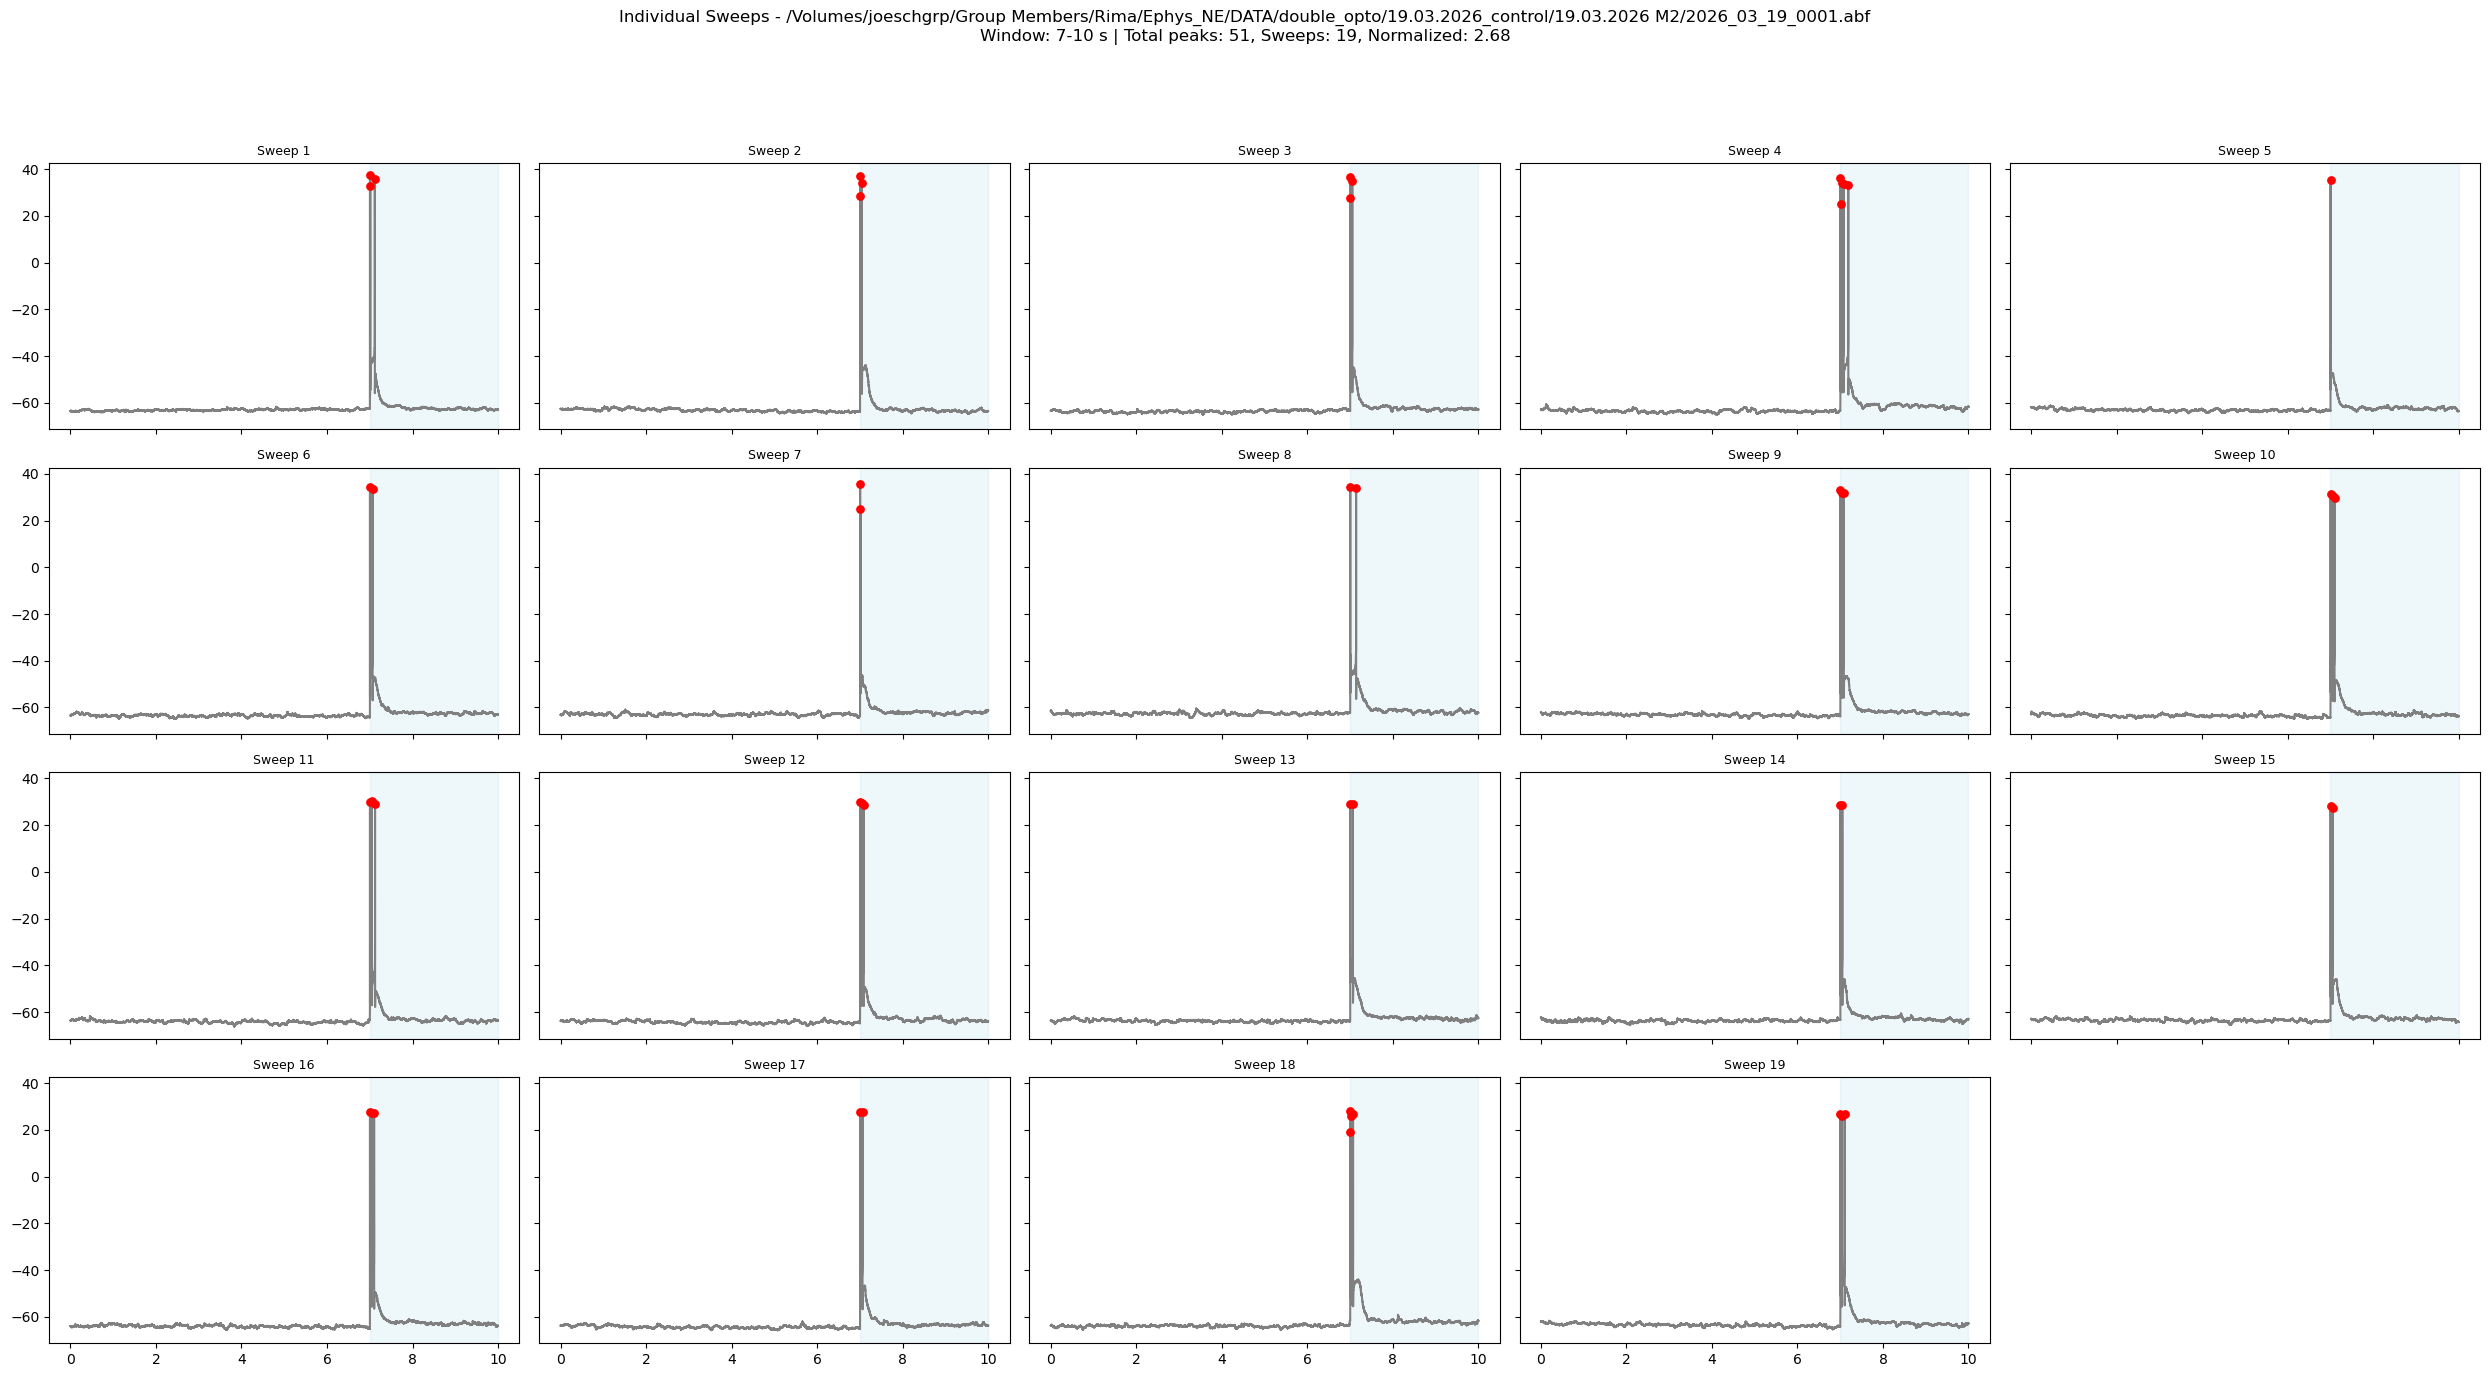

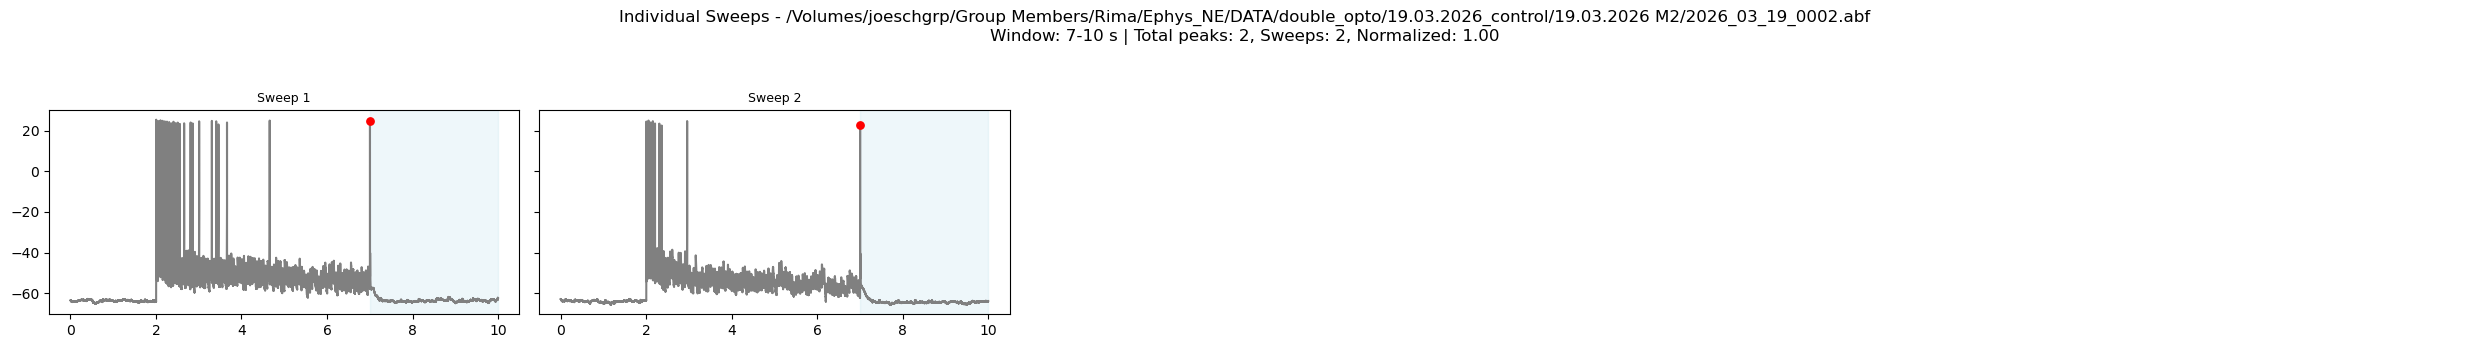

' df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"] )\ncsv_file_path = "/Users/rbondare/ephys_scripts/spikes_summary.csv"\ndf.to_csv(csv_file_path, index=False)\n\nprint(f"Results saved to {csv_file_path}")\ndf '

In [3]:
base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/19.03.2026_control"

# list of abf files for experiments 19.03.2026
abf_files = [
    os.path.join(base_dir, "19.03.2026 M2/2026_03_19_0001.abf"),
    os.path.join(base_dir, "19.03.2026 M2/2026_03_19_0002.abf")
]
def count_and_plot_peaks_per_sweep(
    abf_file,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    detection_window=(7, 10),
):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)

    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 3.5 * n_rows),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes).ravel()

    peak_counts = []
    total_peaks = 0

    for i, sweep in enumerate(abf.sweepList):
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        window_mask = (x >= detection_window[0]) & (x <= detection_window[1])
        x_window = x[window_mask]
        y_window = y[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
        else:
            peaks = np.array([], dtype=int)

        n_peaks = len(peaks)
        peak_counts.append(n_peaks)
        total_peaks += n_peaks

        ax = axes[i]
        ax.plot(x, y, color="gray", linewidth=1.5)
        ax.axvspan(detection_window[0], detection_window[1], color="lightblue", alpha=0.2)
        if n_peaks > 0:
            ax.scatter(x[peaks], y[peaks], color="red", s=28, zorder=3)

        ax.set_title(f"Sweep {sweep + 1}", fontsize=9)

    # Hide unused axes
    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")
    for ax in axes[:n_sweeps]:
        ax.label_outer()

    norm_spikes = total_peaks / n_sweeps if n_sweeps > 0 else 0

    plt.suptitle(
        f"Individual Sweeps - {abf_file}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s | "
        f"Total peaks: {total_peaks}, Sweeps: {n_sweeps}, Normalized: {norm_spikes:.2f}",
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    return abf_file, norm_spikes, peak_counts

# Process each file, visualize peaks per sweep, and collect summary
results = []
for abf_file in abf_files:
    file_path, norm_spikes, peak_counts = count_and_plot_peaks_per_sweep(
        abf_file, height_threshold=4, detection_window=(7, 10)
    )
    results.append([file_path, f"{norm_spikes:.2f}", peak_counts])

df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"])

# Save summary to CSV
""" df = pd.DataFrame(results, columns=["File Name", "Normalized Spikes per Sweep", "Peaks Per Sweep"] )
csv_file_path = "/Users/rbondare/ephys_scripts/spikes_summary.csv"
df.to_csv(csv_file_path, index=False)

print(f"Results saved to {csv_file_path}")
df """

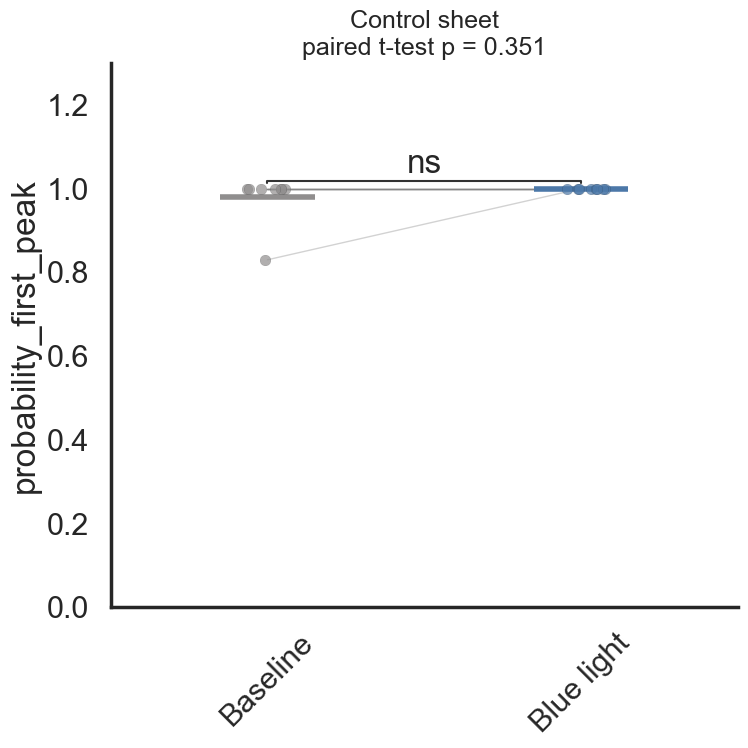

,Cell_ID,Baseline_Value,Blue_Value,Delta,Percent_Change
0,1,1.0,1.0,0.0,0.0
1,2,1.0,1.0,0.0,0.0
2,3,1.0,1.0,0.0,0.0
3,4,1.0,1.0,0.0,0.0
4,5,1.0,1.0,0.0,0.0


In [8]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statannotations.Annotator import Annotator

sns.set_context("poster")
sns.set_style("white")

# =============================================================================
# USER SETTINGS
# =============================================================================

results_table_path = "/Users/rbondare/ephys/results/double_opto_database.xlsx"
sheet_name = "Control"

id_col = "ID"
condition_col = "condition"
value_col = "probability_first_peak"
alternate_value_col = "probability_first_peak" #"normalized all peaks"

baseline_label = "baseline"
blue_label = "blue light"
y_label = "probability_first_peak"

# =============================================================================
# DATA PREPARATION
# =============================================================================

def prepare_paired_dataset_from_condition(df, id_col, condition_col, value_col):
    df = df.copy()
    if condition_col not in df.columns:
        raise KeyError(f"Missing condition column: {condition_col}\nAvailable: {list(df.columns)}")

    if value_col not in df.columns and alternate_value_col in df.columns:
        value_col = alternate_value_col
    if value_col not in df.columns:
        raise KeyError(f"Missing value column: {value_col}\nAvailable: {list(df.columns)}")

    if 'comment' in df.columns:
        exclude_mask = df['comment'].astype(str).str.contains('Exclude', case=False, na=False)
        df = df.loc[~exclude_mask].copy()

    cond = df[condition_col].astype(str).str.strip().str.lower()

    baseline_rows = df[cond == baseline_label][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Baseline_Value'})
    blue_rows = df[cond.str.contains('blue light', na=False)][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Blue_Value'})

    baseline_rows['Baseline_Value'] = pd.to_numeric(baseline_rows['Baseline_Value'], errors='coerce')
    blue_rows['Blue_Value'] = pd.to_numeric(blue_rows['Blue_Value'], errors='coerce')

    baseline_agg = baseline_rows.groupby('Cell_ID', as_index=False)['Baseline_Value'].mean()
    blue_agg = blue_rows.groupby('Cell_ID', as_index=False)['Blue_Value'].mean()

    paired = pd.merge(baseline_agg, blue_agg, on='Cell_ID', how='inner')
    paired['Delta'] = paired['Blue_Value'] - paired['Baseline_Value']
    paired['Percent_Change'] = np.where(
        paired['Baseline_Value'] != 0,
        paired['Delta'] / paired['Baseline_Value'] * 100,
        np.nan,
    )
    return paired


# =============================================================================
# STATISTICS
# =============================================================================

def compute_paired_stats(paired_df):
    paired_t = stats.ttest_rel(paired_df['Baseline_Value'], paired_df['Blue_Value'], nan_policy='omit')
    try:
        wilcoxon_p = stats.wilcoxon(paired_df['Baseline_Value'], paired_df['Blue_Value']).pvalue
    except ValueError:
        wilcoxon_p = np.nan
    return paired_t.pvalue, wilcoxon_p


# =============================================================================
# PLOTTING
# =============================================================================

def paired_plot(ax, data, title):
    conditions = ['Baseline', 'Blue light']
    colors_fill = ['lightgrey', 'lightskyblue']
    colors_points = ['#908E8E', '#4C78A8']
    jitter_amount = 0.08
    rng = np.random.default_rng(42)

    box_data = [data['Baseline_Value'].values, data['Blue_Value'].values]
    bp = ax.boxplot(
        box_data,
        positions=[0, 1],
        widths=0.28,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color='none'),
        boxprops=dict(edgecolor='none'),
        whiskerprops=dict(color='none'),
        capprops=dict(color='none'),
    )

    for patch, color in zip(bp['boxes'], colors_fill):
        patch.set_facecolor(color)
        patch.set_alpha(0.9)

    for _, row in data.iterrows():
        x0 = 0 + rng.uniform(-jitter_amount, jitter_amount)
        x1 = 1 + rng.uniform(-jitter_amount, jitter_amount)
        ax.plot([0, 1], [row['Baseline_Value'], row['Blue_Value']], color='gray', alpha=0.35, linewidth=1)
        ax.scatter(x0, row['Baseline_Value'], color=colors_points[0], alpha=0.7, s=60, edgecolors='black', linewidths=0.1, zorder=3)
        ax.scatter(x1, row['Blue_Value'], color=colors_points[1], alpha=0.7, s=60, edgecolors='black', linewidths=0.1, zorder=3)

    for i, col in enumerate(['Baseline_Value', 'Blue_Value']):
        ax.hlines(data[col].mean(), i - 0.15, i + 0.15, color=colors_points[i], linewidth=4)

    long_df = pd.DataFrame({
        'value': np.concatenate([data['Baseline_Value'], data['Blue_Value']]),
        'group': ['Baseline'] * len(data) + ['Blue light'] * len(data),
    })

    annotator = Annotator(ax, [('Baseline', 'Blue light')], data=long_df, x='group', y='value')
    annotator.configure(test='t-test_paired', text_format='star', loc='outside', verbose=False)
    annotator.apply_and_annotate()

    ymax = max(data['Baseline_Value'].max(), data['Blue_Value'].max())
    ax.set_xticks([0, 1])
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, ymax * 1.3 if ymax > 0 else 1)
    ax.set_title(title, fontsize=18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# =============================================================================
# RUN ANALYSIS
# =============================================================================

if not os.path.exists(results_table_path):
    raise FileNotFoundError(results_table_path)

source_df = pd.read_excel(results_table_path, sheet_name=sheet_name, header=0)
paired_df = prepare_paired_dataset_from_condition(source_df, id_col=id_col, condition_col=condition_col, value_col=value_col)
paired_p, wilcoxon_p = compute_paired_stats(paired_df)

fig, ax = plt.subplots(figsize=(8, 8))
paired_plot(ax, paired_df, f"Control sheet\npaired t-test p = {paired_p:.3g}")
plt.tight_layout()
plt.show()

pd.options.display.max_columns = None
display(paired_df.head())


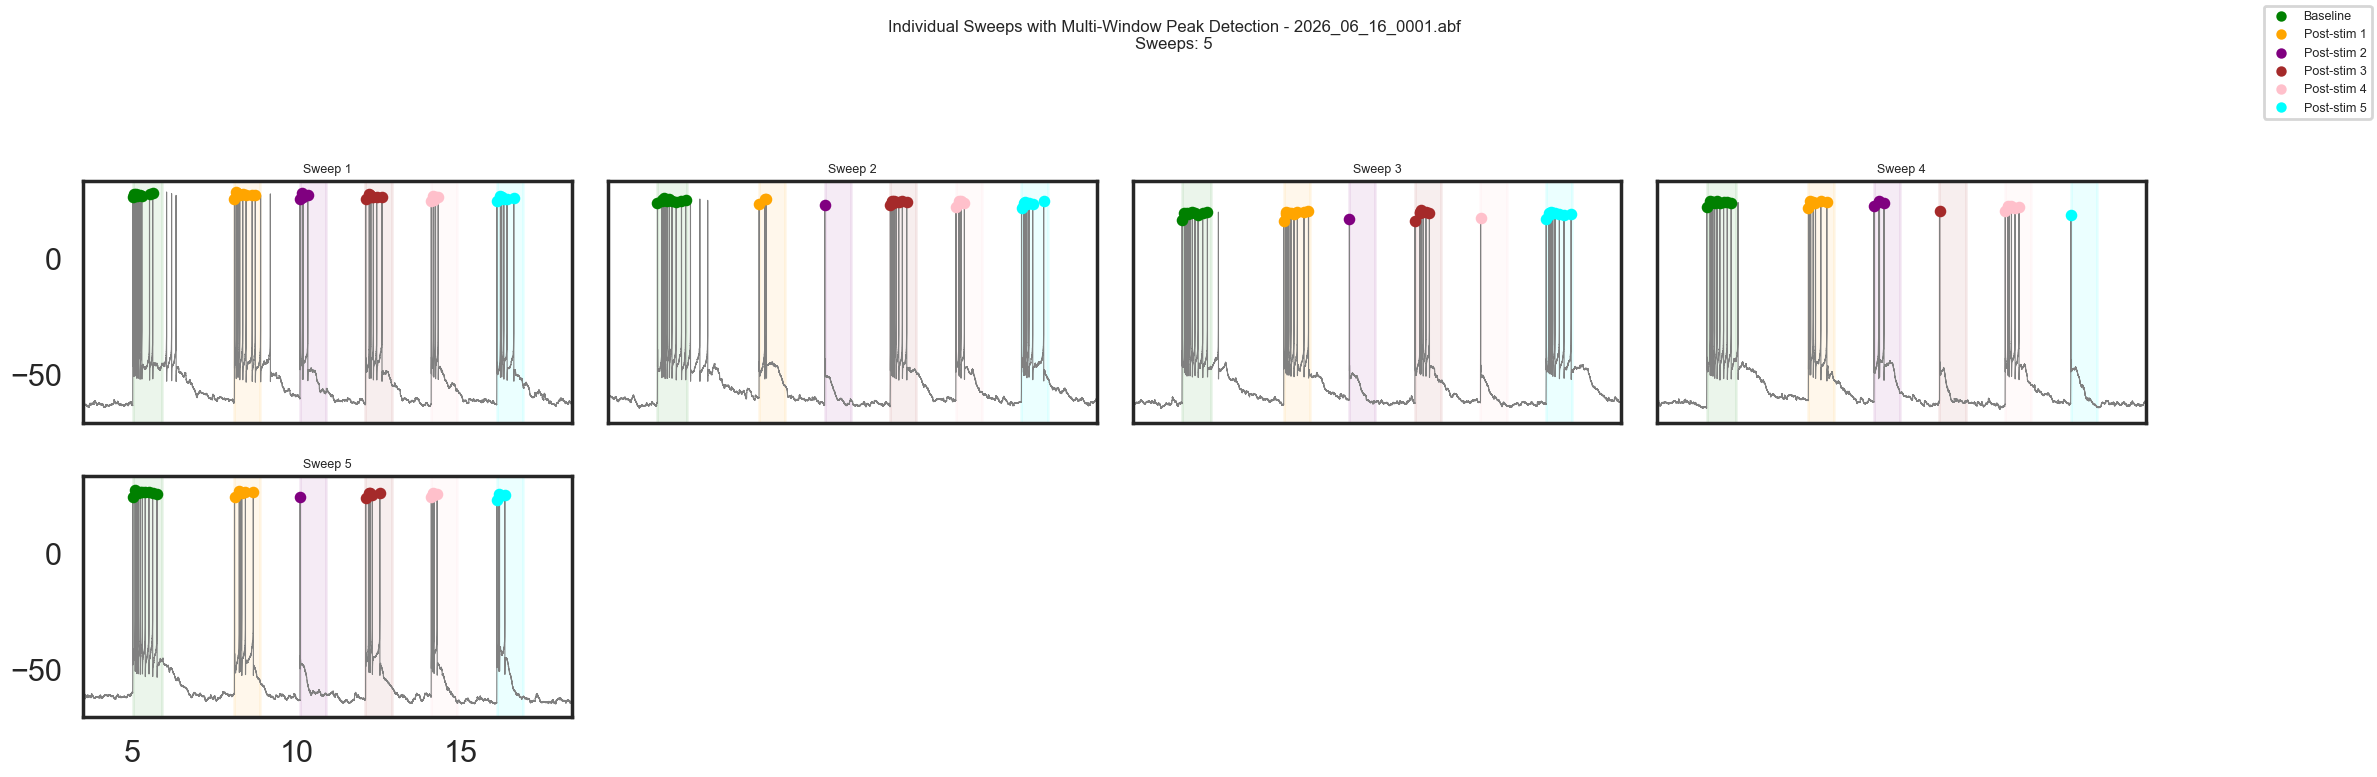

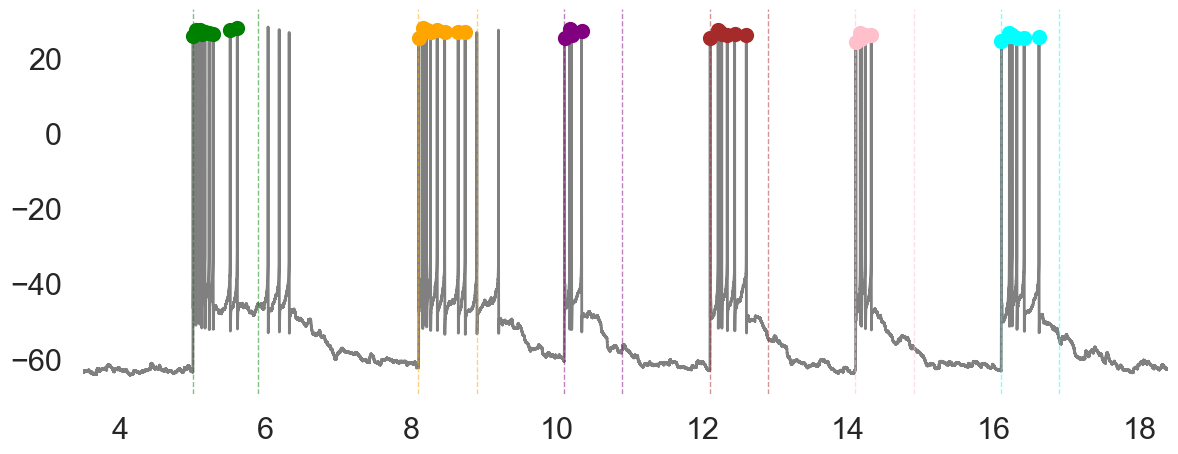

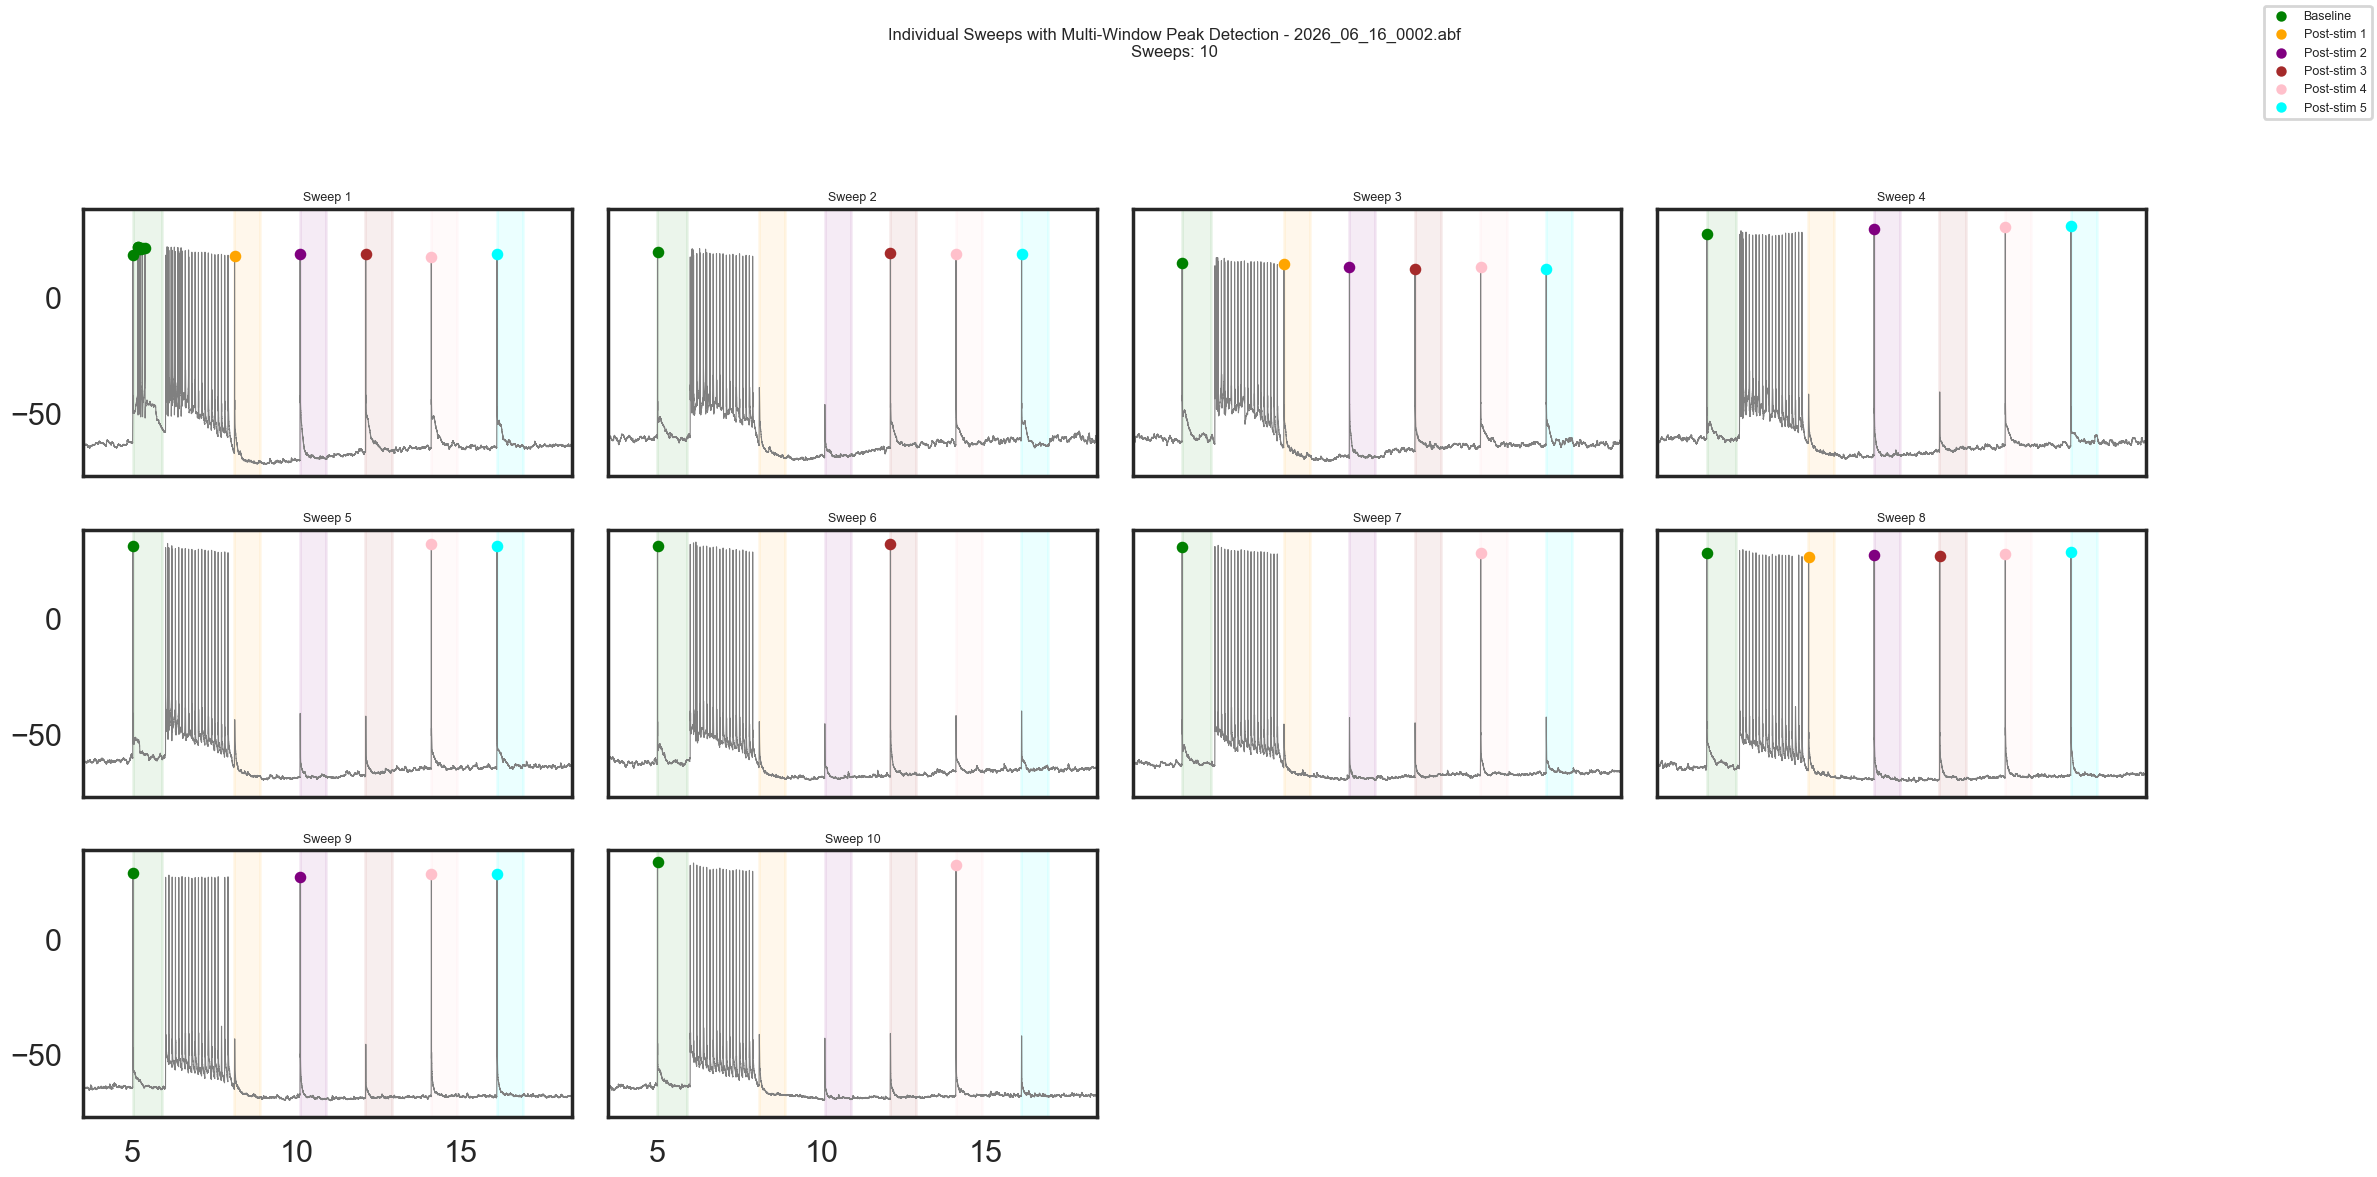

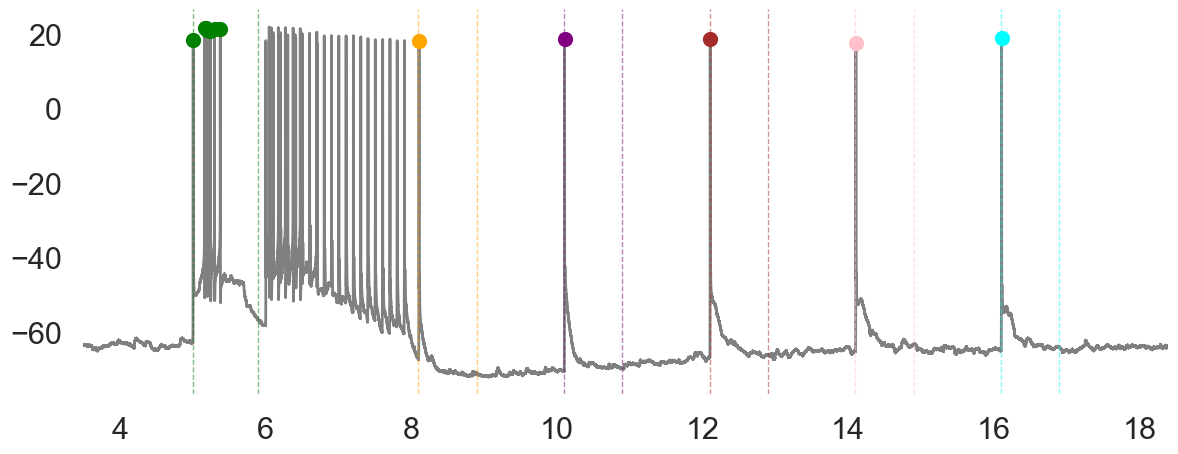

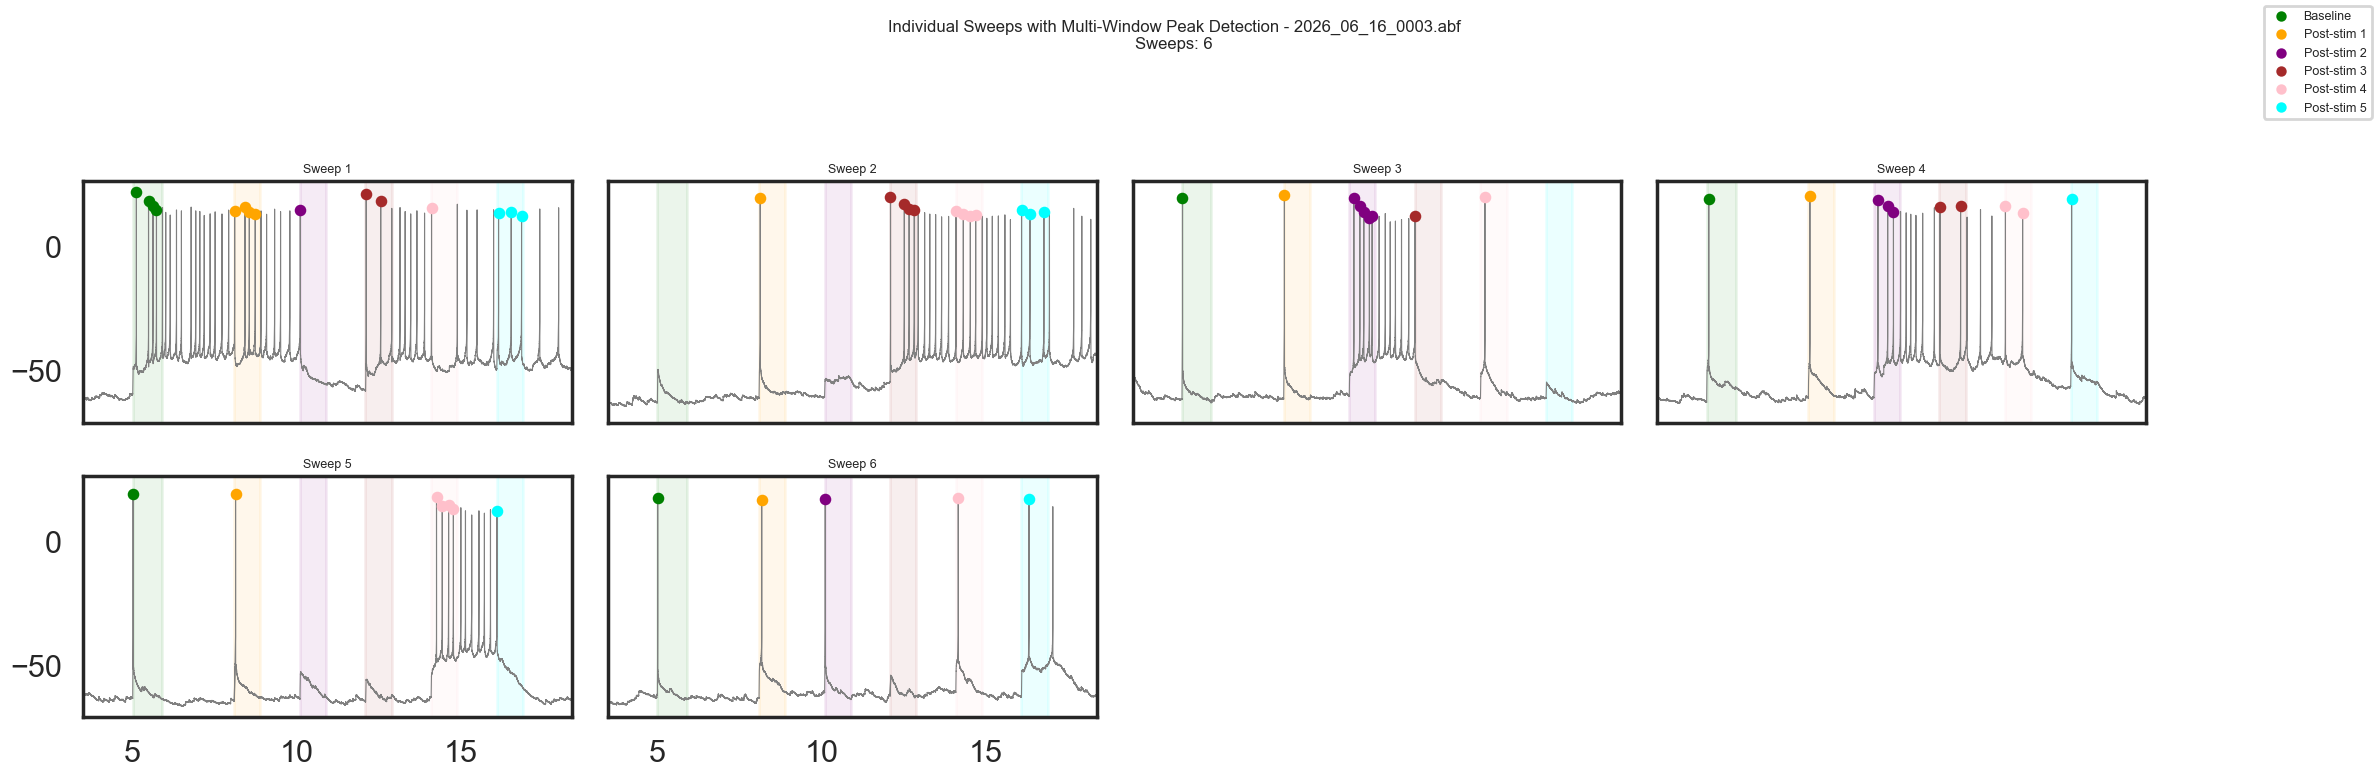

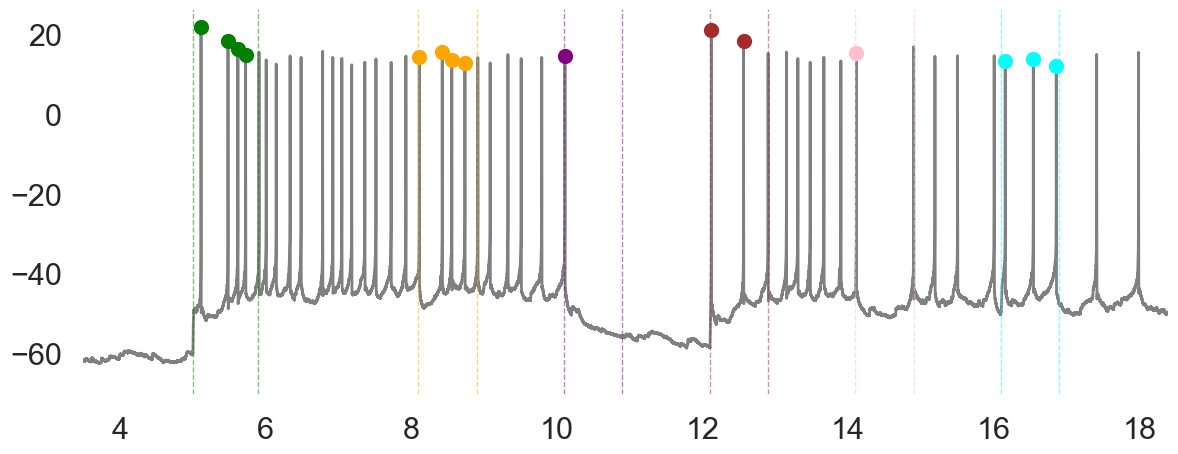

ValueError: ABF file does not exist: /Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026/13.05.2026 M2/2026_05_13_0010.abf

In [9]:
sns.set_context("poster")
sns.set_style("white")

base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026/"

# list of abf files for experiments 19.03.2026
abf_files = [
    os.path.join(base_dir, "16.06.2026 M1/2026_06_16_0001.abf"),
    os.path.join(base_dir, "16.06.2026 M1/2026_06_16_0002.abf"),
    os.path.join(base_dir, "16.06.2026 M1/2026_06_16_0003.abf"),
    os.path.join(base_dir, "13.05.2026 M2/2026_05_13_0010.abf"),
    os.path.join(base_dir, "13.05.2026 M2/2026_05_13_0011.abf"),
    os.path.join(base_dir, "13.05.2026 M2/2026_05_13_0013.abf"),
    os.path.join(base_dir, "13.05.2026 M2/2026_05_13_0014.abf")
]


# Define time windows for each stimulus phase
# Format: (start, end, label, color)
stimulus_windows = [
    (5.0, 5.9, "Baseline", "green"),
    (8.1, 8.9, "Post-stim 1", "orange"),
    (10.1, 10.9, "Post-stim 2", "purple"),
    (12.1, 12.9, "Post-stim 3", "brown"),
    (14.1, 14.9, "Post-stim 4", "pink"),
    (16.1, 16.9, "Post-stim 5", "cyan"),
]

def count_and_plot_peaks_multi_window(
    abf_file,
    stimulus_windows,
    height_threshold=4,
    prominence_min=0.1,
    distance_min=5,
    sweep_to_zoom=0,
    show_grid=True,
    ):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)

    n_cols = 4
    n_rows = int(np.ceil(n_sweeps / n_cols))

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(6 * n_cols, 4 * n_rows),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes).ravel()

    # Dictionary to store peak counts per window per sweep
    peak_counts_by_window = {label: [] for _, _, label, _ in stimulus_windows}
    total_peaks_by_window = {label: 0 for _, _, label, _ in stimulus_windows}

    for i, sweep in enumerate(abf.sweepList):
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        ax = axes[i]
        ax.plot(x, y, color="gray", linewidth=0.8)

        # Shade each stimulus window
        for start, end, label, color in stimulus_windows:
            ax.axvspan(start, end, color=color, alpha=0.08)

        # Process each stimulus window
        for start, end, label, color in stimulus_windows:
            window_mask = (x >= start) & (x <= end)
            x_window = x[window_mask]
            y_window = y[window_mask]

            if y_window.size > 0:
                peaks_window, _ = detect_peaks(
                    y_window,
                    height_threshold=height_threshold,
                    prominence_min=prominence_min,
                    distance_min=distance_min,
                )
                peaks = np.where(window_mask)[0][peaks_window]
            else:
                peaks = np.array([], dtype=int)

            n_peaks = len(peaks)
            peak_counts_by_window[label].append(n_peaks)
            total_peaks_by_window[label] += n_peaks

            if n_peaks > 0:
                ax.scatter(x[peaks], y[peaks], color=color, s=40, zorder=3)

        ax.set_title(f"Sweep {sweep + 1}", fontsize=9)

    # Zoom x-axis to the stimulus window region with some padding
    x_start = stimulus_windows[0][0] - 1.5
    x_end = stimulus_windows[-1][1] + 1.5
    axes[0].set_xlim(x_start, x_end)

    # Hide unused axes
    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")
    for ax in axes[:n_sweeps]:
        ax.label_outer()

    # Create legend with window labels and colors
    legend_elements = [
        plt.scatter([], [], color=color, s=30, label=label)
        for _, _, label, color in stimulus_windows
    ]
    fig.legend(handles=legend_elements, loc="upper right", fontsize=9)

    plt.suptitle(
        f"Individual Sweeps with Multi-Window Peak Detection - {os.path.basename(abf_file)}\n"
        f"Sweeps: {n_sweeps}",
        fontsize=12
    )
    plt.tight_layout(rect=[0, 0, 0.92, 0.93])
    plt.show()

    # Create large detailed plot of sweep `sweep_to_zoom` (default 0)
    zoom_idx = max(0, min(sweep_to_zoom, n_sweeps-1))
    fig_zoom, ax_zoom = plt.subplots(figsize=(14, 5))

    abf.setSweep(zoom_idx)
    x_sweep1 = abf.sweepX
    y_sweep1 = abf.sweepY

    ax_zoom.plot(x_sweep1, y_sweep1, color="gray", linewidth=2.0)

    # Process and plot peaks for each stimulus window
    for start, end, label, color in stimulus_windows:
        window_mask = (x_sweep1 >= start) & (x_sweep1 <= end)
        x_window = x_sweep1[window_mask]
        y_window = y_sweep1[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
        else:
            peaks = np.array([], dtype=int)

        if len(peaks) > 0:
            ax_zoom.scatter(x_sweep1[peaks], y_sweep1[peaks], color=color, s=80, zorder=3, label=label)
            ax_zoom.axvline(start, color=color, linestyle="--", alpha=0.5, linewidth=1)
            ax_zoom.axvline(end, color=color, linestyle="--", alpha=0.5, linewidth=1)

    ax_zoom.set_xlim(x_start, x_end)

    for spine in ["top", "right"]:
        ax_zoom.spines[spine].set_visible(False)
    ax_zoom.spines["bottom"].set_visible(False)
    ax_zoom.spines["left"].set_visible(False)

    ax_zoom.set_facecolor("none")
    fig_zoom.patch.set_facecolor("white")
    plt.show()

    return abf_file, peak_counts_by_window, total_peaks_by_window

# Process each file
results_multi_window = []
for abf_file in abf_files:
    file_path, peak_counts_by_window, total_peaks_by_window = count_and_plot_peaks_multi_window(
        abf_file, stimulus_windows, height_threshold=4, sweep_to_zoom=0
    )
    results_multi_window.append({
        "file": os.path.basename(abf_file),
        "peak_counts_by_window": peak_counts_by_window,
        "total_peaks_by_window": total_peaks_by_window,
    })

# Create summary table: normalized peak count per stimulus window + sweep-1 counts
summary_data = []
for result in results_multi_window:
    row = {"File": result["file"]}
    if len(result["peak_counts_by_window"])>0:
        n_sweeps = len(next(iter(result["peak_counts_by_window"].values())))
    else:
        n_sweeps = 0
    for _, _, label, _ in stimulus_windows:
        total = result["total_peaks_by_window"].get(label, 0)
        avg = total / n_sweeps if n_sweeps>0 else 0
        sweep1_count = result["peak_counts_by_window"].get(label, [0])[0] if n_sweeps>0 else 0
        row[f"{label} avg"] = f"{avg:.2f}"
        row[f"{label} sweep1"] = int(sweep1_count)
    summary_data.append(row)

df_summary = pd.DataFrame(summary_data)
df_summary

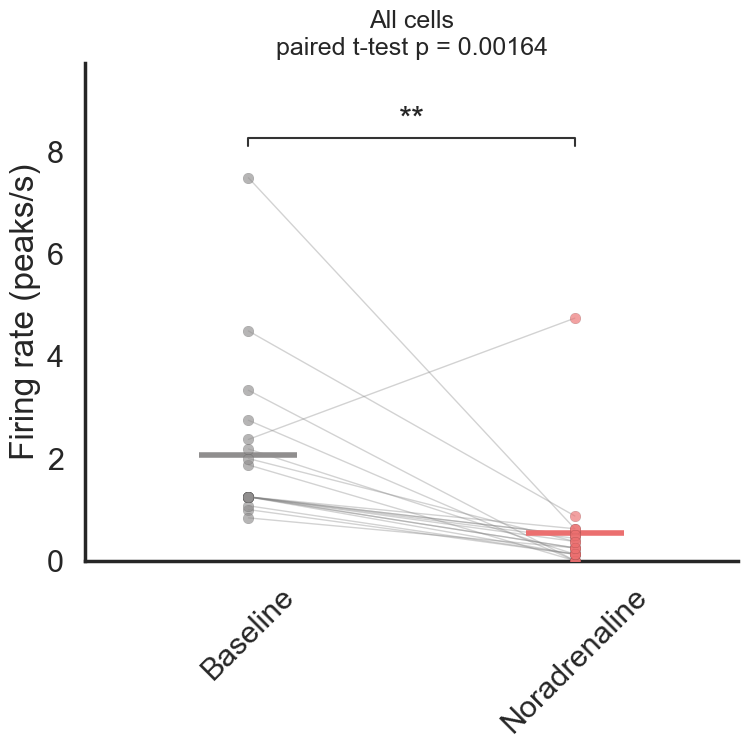

,Cell_ID,Baseline_Counts,NA_Counts,Baseline_FR,NA_FR,Delta_FR,Percent_Change,Fold_Change
0,1,1.00,0.3,1.2500,0.375,-0.8750,-70.000000,0.300000
1,2,1.75,0.1,2.1875,0.125,-2.0625,-94.285714,0.057143
2,3,1.90,3.8,2.3750,4.750,2.3750,100.000000,2.000000
3,4,1.00,0.4,1.2500,0.500,-0.7500,-60.000000,0.400000
4,5,1.00,0.5,1.2500,0.625,-0.6250,-50.000000,0.500000


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statannotations.Annotator import Annotator

sns.set_context("poster")
sns.set_style("white")

# =============================================================================
# USER SETTINGS 
# =============================================================================

results_table_path = "/Users/rbondare/ephys/results/double_opto_database_V2.xlsx"
sheet_name = "Noradrenaline"

id_col = "ID"
# we'll extract post_stim_3_avg for both baseline and NA conditions
poststim_col = "post_stim_3_avg"

# time window (s) over which counts were measured
time_window = 0.8

baseline_label = "Baseline"
na_label = "Noradrenaline"

y_label = "Firing rate (peaks/s)"


# =============================================================================
# DATA PREPARATION
# =============================================================================

def prepare_paired_dataset_from_condition(df, id_col, condition_col, value_col):
    # Select rows for baseline and noradrenaline conditions and take mean per ID
    df = df.copy()
    if condition_col not in df.columns:
        raise KeyError(f"Missing condition column: {condition_col}\nAvailable: {list(df.columns)}")

    # normalize condition strings for matching
    cond = df[condition_col].astype(str).str.strip().str.lower()

    baseline_rows = df[cond == 'baseline'][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Baseline_Counts'})
    na_rows = df[cond.str.contains('noradrenaline')][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'NA_Counts'})

    # coerce numeric and groupby mean in case of duplicates
    baseline_rows['Baseline_Counts'] = pd.to_numeric(baseline_rows['Baseline_Counts'], errors='coerce')
    na_rows['NA_Counts'] = pd.to_numeric(na_rows['NA_Counts'], errors='coerce')

    baseline_agg = baseline_rows.groupby('Cell_ID', as_index=False)['Baseline_Counts'].mean()
    na_agg = na_rows.groupby('Cell_ID', as_index=False)['NA_Counts'].mean()

    # merge on Cell_ID — keep only cells that have both baseline and NA
    paired = pd.merge(baseline_agg, na_agg, on='Cell_ID', how='inner')

    # compute firing rates (peaks per second) from counts-per-sweep
    paired['Baseline_FR'] = paired['Baseline_Counts'] / time_window
    paired['NA_FR'] = paired['NA_Counts'] / time_window

    paired['Delta_FR'] = paired['NA_FR'] - paired['Baseline_FR']
    paired['Percent_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['Delta_FR'] / paired['Baseline_FR'] * 100,
        np.nan,
    )
    paired['Fold_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['NA_FR'] / paired['Baseline_FR'],
        np.nan,
    )

    return paired


# =============================================================================
# STATISTICS
# =============================================================================

def compute_paired_stats(paired_df):
    paired_t = stats.ttest_rel(paired_df["Baseline_FR"], paired_df["NA_FR"], nan_policy="omit")

    try:
        wilcoxon_result = stats.wilcoxon(paired_df["Baseline_FR"], paired_df["NA_FR"])
        wilcoxon_p = wilcoxon_result.pvalue
    except ValueError:
        wilcoxon_p = np.nan

    return paired_t.pvalue, wilcoxon_p


# =============================================================================
# MAIN PAIRED PLOT 
# =============================================================================

def paired_plot(ax, data, title):
    conditions = [baseline_label, na_label]
    colors_fill = ["lightgrey", "lightcoral"]
    colors_points = ["#908E8E", "#EB6F6F"]

    box_data = [data["Baseline_FR"].values, data["NA_FR"].values]

    ax.boxplot(
        box_data,
        positions=range(2),
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="none"),
        boxprops=dict(facecolor="none", edgecolor="none"),
        whiskerprops=dict(color="none"),
        capprops=dict(color="none"),
    )

    for i, patch in enumerate(ax.artists):
        patch.set_facecolor(colors_fill[i])
        patch.set_alpha(0.9)

    for _, row in data.iterrows():
        y = [row["Baseline_FR"], row["NA_FR"]]
        x = [0, 1]

        ax.plot(x, y, color="gray", alpha=0.35, linewidth=1)

        for j, yi in enumerate(y):
            ax.scatter(
                x[j], yi,
                color=colors_points[j],
                alpha=0.65,
                s=60,
                edgecolors="black",
                linewidths=0.1,
                zorder=3,
            )

    for i, col in enumerate(["Baseline_FR", "NA_FR"]):
        mean_y = data[col].mean()
        ax.hlines(mean_y, i - 0.15, i + 0.15, color=colors_points[i], linewidth=4)

    plot_long = pd.DataFrame({
        "value": np.concatenate([data["Baseline_FR"], data["NA_FR"]]),
        "group": [baseline_label] * len(data) + [na_label] * len(data),
    })

    annotator = Annotator(ax, [(baseline_label, na_label)], data=plot_long, x="group", y="value")
    annotator.configure(test="t-test_paired", text_format="star", loc="outside", verbose=False)
    annotator.apply_and_annotate()

    max_y = max(data["Baseline_FR"].max(), data["NA_FR"].max())

    ax.set_xticks([0, 1])
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, max_y * 1.3 if max_y > 0 else 1)
    ax.set_title(title, fontsize=18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# =============================================================================
# RUN ANALYSIS
# =============================================================================

if not os.path.exists(results_table_path):
    raise FileNotFoundError(results_table_path)

source_df = pd.read_excel(results_table_path, sheet_name=sheet_name, header=1)

paired_df = prepare_paired_dataset_from_condition(source_df, id_col=id_col, condition_col='condition', value_col=poststim_col)

paired_p, wilcoxon_p = compute_paired_stats(paired_df)

fig, ax = plt.subplots(figsize=(8, 8))
paired_plot(ax, paired_df, f"All cells\npaired t-test p = {paired_p:.3g}")
plt.tight_layout()
plt.show()

# show both counts and firing rates for verification
pd.options.display.max_columns = None
display(paired_df.head())


Control Recordings Plots

/Users/rbondare/miniforge3/envs/ephys/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


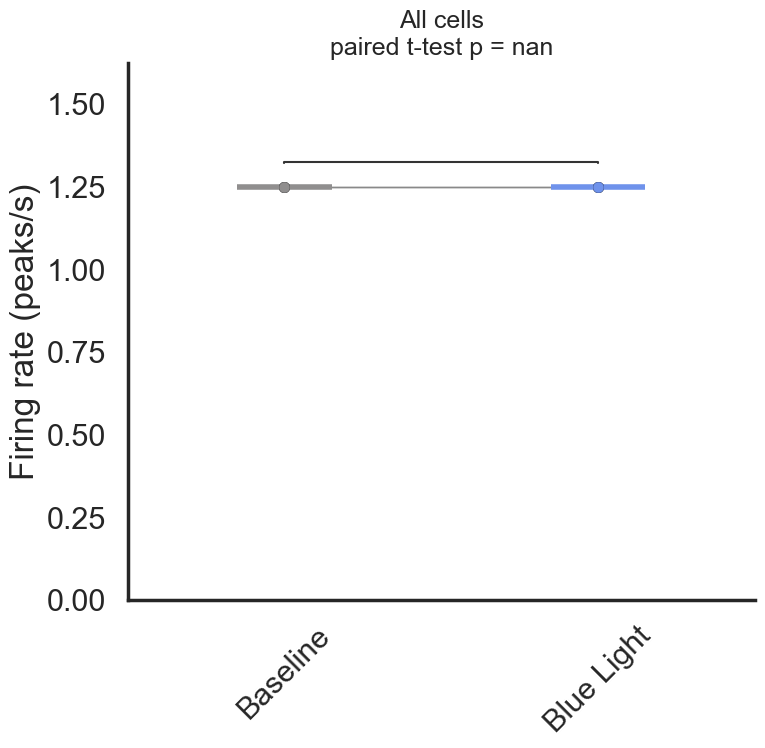

,Cell_ID,Baseline_Counts,blue_Counts,Baseline_FR,NA_FR,Delta_FR,Percent_Change,Fold_Change
0,1,1.0,1.0,1.25,1.25,0.0,0.0,1.0
1,2,1.0,1.0,1.25,1.25,0.0,0.0,1.0
2,3,1.0,1.0,1.25,1.25,0.0,0.0,1.0
3,4,1.0,1.0,1.25,1.25,0.0,0.0,1.0
4,5,1.0,1.0,1.25,1.25,0.0,0.0,1.0


In [1]:
"""same plotting but for the RRRB control recordings"""

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statannotations.Annotator import Annotator

sns.set_context("poster")
sns.set_style("white")

# =============================================================================
# USER SETTINGS 
# =============================================================================

results_table_path = "/Users/rbondare/ephys/results/double_opto_database_V3.xlsx"
sheet_name = "Control"

id_col = "ID"
# we'll extract post_stim_3_avg for both baseline and NA conditions
poststim_col = "post_stim_3_avg"

# time window (s) over which counts were measured
time_window = 0.8

baseline_label = "Baseline"
blue_label = "Blue Light"

y_label = "Firing rate (peaks/s)"


# =============================================================================
# DATA PREPARATION
# =============================================================================

def prepare_paired_dataset_from_condition(df, id_col, condition_col, value_col):
    # Select rows for baseline and blue light conditions and take mean per ID
    df = df.copy()
    if condition_col not in df.columns:
        raise KeyError(f"Missing condition column: {condition_col}\nAvailable: {list(df.columns)}")

    # normalize condition strings for matching
    cond = df[condition_col].astype(str).str.strip().str.lower()

    baseline_rows = df[cond == 'baseline'][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'Baseline_Counts'})
    na_rows = df[cond.str.contains('blue light')][[id_col, value_col]].rename(columns={id_col: 'Cell_ID', value_col: 'blue_Counts'})

    # coerce numeric and groupby mean in case of duplicates
    baseline_rows['Baseline_Counts'] = pd.to_numeric(baseline_rows['Baseline_Counts'], errors='coerce')
    na_rows['blue_Counts'] = pd.to_numeric(na_rows['blue_Counts'], errors='coerce')

    baseline_agg = baseline_rows.groupby('Cell_ID', as_index=False)['Baseline_Counts'].mean()
    na_agg = na_rows.groupby('Cell_ID', as_index=False)['blue_Counts'].mean()

    # merge on Cell_ID — keep only cells that have both baseline and NA
    paired = pd.merge(baseline_agg, na_agg, on='Cell_ID', how='inner')

    # compute firing rates (peaks per second) from counts-per-sweep
    paired['Baseline_FR'] = paired['Baseline_Counts'] / time_window
    paired['NA_FR'] = paired['blue_Counts'] / time_window

    paired['Delta_FR'] = paired['NA_FR'] - paired['Baseline_FR']
    paired['Percent_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['Delta_FR'] / paired['Baseline_FR'] * 100,
        np.nan,
    )
    paired['Fold_Change'] = np.where(
        paired['Baseline_FR'] != 0,
        paired['NA_FR'] / paired['Baseline_FR'],
        np.nan,
    )

    return paired


# =============================================================================
# STATISTICS
# =============================================================================

def compute_paired_stats(paired_df):
    paired_t = stats.ttest_rel(paired_df["Baseline_FR"], paired_df["NA_FR"], nan_policy="omit")

    try:
        wilcoxon_result = stats.wilcoxon(paired_df["Baseline_FR"], paired_df["NA_FR"])
        wilcoxon_p = wilcoxon_result.pvalue
    except ValueError:
        wilcoxon_p = np.nan

    return paired_t.pvalue, wilcoxon_p


# =============================================================================
# MAIN PAIRED PLOT 
# =============================================================================

def paired_plot(ax, data, title):
    conditions = [baseline_label, blue_label]
    colors_fill = ["lightgrey", "lightblue"]
    colors_points = ["#908E8E", "#6F92EB"]

    box_data = [data["Baseline_FR"].values, data["NA_FR"].values]

    ax.boxplot(
        box_data,
        positions=range(2),
        widths=0.3,
        patch_artist=True,
        showfliers=False,
        medianprops=dict(color="none"),
        boxprops=dict(facecolor="none", edgecolor="none"),
        whiskerprops=dict(color="none"),
        capprops=dict(color="none"),
    )

    for i, patch in enumerate(ax.artists):
        patch.set_facecolor(colors_fill[i])
        patch.set_alpha(0.9)

    for _, row in data.iterrows():
        y = [row["Baseline_FR"], row["NA_FR"]]
        x = [0, 1]

        ax.plot(x, y, color="gray", alpha=0.35, linewidth=1)

        for j, yi in enumerate(y):
            ax.scatter(
                x[j], yi,
                color=colors_points[j],
                alpha=0.65,
                s=60,
                edgecolors="black",
                linewidths=0.1,
                zorder=3,
            )

    for i, col in enumerate(["Baseline_FR", "NA_FR"]):
        mean_y = data[col].mean()
        ax.hlines(mean_y, i - 0.15, i + 0.15, color=colors_points[i], linewidth=4)

    plot_long = pd.DataFrame({
        "value": np.concatenate([data["Baseline_FR"], data["NA_FR"]]),
        "group": [baseline_label] * len(data) + [blue_label] * len(data),
    })

    annotator = Annotator(ax, [(baseline_label, blue_label)], data=plot_long, x="group", y="value")
    annotator.configure(test="t-test_paired", text_format="star", loc="outside", verbose=False)
    annotator.apply_and_annotate()

    max_y = max(data["Baseline_FR"].max(), data["NA_FR"].max())

    ax.set_xticks([0, 1])
    ax.set_xticklabels(conditions, rotation=45)
    ax.set_ylabel(y_label)
    ax.set_ylim(0, max_y * 1.3 if max_y > 0 else 1)
    ax.set_title(title, fontsize=18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# =============================================================================
# RUN ANALYSIS
# =============================================================================

if not os.path.exists(results_table_path):
    raise FileNotFoundError(results_table_path)

source_df = pd.read_excel(results_table_path, sheet_name=sheet_name, header=1)

paired_df = prepare_paired_dataset_from_condition(source_df, id_col=id_col, condition_col='condition', value_col=poststim_col)

paired_p, wilcoxon_p = compute_paired_stats(paired_df)

fig, ax = plt.subplots(figsize=(8, 8))
paired_plot(ax, paired_df, f"All cells\npaired t-test p = {paired_p:.3g}")
plt.tight_layout()
plt.show()

# show both counts and firing rates for verification
pd.options.display.max_columns = None
display(paired_df.head())

### Poster figure: single-cell example trace
Same dashed-line/no-marker style as the zoomed single-sweep plot above (multi-window
peak-detection cell), but for one representative cell (Noradrenaline, ID 18) with blue
light shaded separately from the red-pulse detection windows.

In [ ]:
"""Poster figure: single-cell example trace (Noradrenaline, ID 18, sweep 1).

Same style as the zoomed single-sweep plot in the multi-window peak-detection cell:
gray trace, dashed lines marking each red-pulse detection window (no marker on the
peak itself), spines removed for a clean poster look. Blue light (6-8s, triggers NA
release) is shaded separately in blue so its timing relative to the baseline pulse and
the suppressed/recovering post-stim pulses is explicit.

ID 18 / sweep 1 was picked because it shows the suppression-then-recovery story cleanly
in a single trial: one spike at baseline, none during NA or the early post-stim pulses,
one spike returns by the last post-stim pulse (Wash).
"""

import pyabf
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import seaborn as sns

sns.set_context("poster")
sns.set_style("white")

EXAMPLE_ABF = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026/18.06.2026 M5/2026_06_18_0009.abf"
SWEEP_TO_PLOT = 0

BLUE_LIGHT_WINDOW = (6.0, 8.0)
STIMULUS_WINDOWS = [
    (5.0, 5.9, "Baseline", "green"),
    (8.1, 8.9, "Post-stim 1", "orange"),
    (10.1, 10.9, "Post-stim 2", "purple"),
    (12.1, 12.9, "Post-stim 3", "brown"),
    (14.1, 14.9, "Post-stim 4", "pink"),
    (16.1, 16.9, "Post-stim 5 (Wash)", "cyan"),
]

abf = pyabf.ABF(EXAMPLE_ABF)
abf.setSweep(SWEEP_TO_PLOT)
x = abf.sweepX
y = abf.sweepY

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(x, y, color="gray", linewidth=2.0)

# blue light epoch (triggers NA release), shaded distinctly from the detection windows
ax.axvspan(*BLUE_LIGHT_WINDOW, color="blue", alpha=0.12, zorder=0)

# dashed lines marking each red-pulse detection window -- no marker on the peak itself
for start, end, label, color in STIMULUS_WINDOWS:
    ax.axvline(start, color=color, linestyle="--", alpha=0.6, linewidth=1.3)
    ax.axvline(end, color=color, linestyle="--", alpha=0.6, linewidth=1.3)

x_start = STIMULUS_WINDOWS[0][0] - 1.5
x_end = STIMULUS_WINDOWS[-1][1] + 1.5
ax.set_xlim(x_start, x_end)

for spine in ["top", "right", "bottom", "left"]:
    ax.spines[spine].set_visible(False)
ax.set_facecolor("none")
fig.patch.set_facecolor("white")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Membrane potential (mV)")
ax.set_title("Example cell (Noradrenaline, ID 18)")

legend_elements = [mlines.Line2D([], [], color="blue", alpha=0.4, linewidth=8, label="Blue light")]
legend_elements += [
    mlines.Line2D([], [], color=color, linestyle="--", linewidth=1.5, label=label)
    for _, _, label, color in STIMULUS_WINDOWS
]
ax.legend(handles=legend_elements, frameon=False, loc="upper right", fontsize=11)

plt.tight_layout()
plt.savefig("/Users/rbondare/ephys-1/figures/poster_example_cell_trace.png", dpi=300, bbox_inches="tight")
plt.show()


### Poster figure: Control vs Noradrenaline, 3-point trajectory (genotype-figure style)
One figure, two side-by-side panels (Control | Noradrenaline) sharing a symlog y-axis.
Styled to match `plot_by_genotype_figure` from `ephys_functions.py` exactly: translucent
boxplot bands behind each x position, per-cell jittered scatter points connected by thin
gray lines, and thick colored median bars (position-coded gray -> coral -> light blue).

Trajectory points are baseline -> post_stim_2 (+5.1s) -> post_stim_5 (+11.1s), i.e. the
double-opto analog of the classic baseline/NA/wash design. The Noradrenaline panel's last
point is labeled "Wash" since firing rate has largely recovered by that pulse; the Control
panel's last point stays labeled "Blue" since it's the same light-only condition throughout.

In [ ]:
"""Poster figure: Control vs NA, 3-point trajectory (baseline -> 2nd post-stim -> 5th/last
post-stim), combined into one figure as two side-by-side panels sharing a linear y-axis.

Per-cell jittered scatter points connected by thin gray lines, with a thick median bar per
x position (style copied from ephys_functions.plot_by_genotype_figure, minus the boxplot
bands). Control is kept uniformly gray throughout since it has no real effect to highlight;
only the Noradrenaline panel uses the position-coded gray -> coral -> light blue scheme.

Significance brackets (paired t-test, all 3 pairwise comparisons among baseline /
2nd point / 3rd point) are drawn above each panel so the suppression-then-partial-recovery
story is backed by numbers, not just visual impression.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_context("poster")
sns.set_style("white")

RESULTS_TABLE_PATH = "/Users/rbondare/ephys/results/double_opto_database_V4.xlsx"
TIME_WINDOW = 0.8

PANELS = [
    {
        "title": "Control (blue light)",
        "sheet_name": "Control",
        "stim_condition": "blue light",
        "labels": ["baseline", "Blue Light\n(+5.1s)", "Post-Stim\n(+11.1s)"],
        "colors": ["#A2A0A0", "#A2A0A0", "#A2A0A0"],
    },
    {
        "title": "Noradrenaline",
        "sheet_name": "Noradrenaline",
        "stim_condition": "noradrenaline",
        "labels": ["baseline", "NA\n(+5.1s)", "Post-Stim\n(+11.1s)"],
        "colors": ["#A2A0A0", "#EB6F6F", "#89CFF0"],
    },
]


def load_trajectory(sheet_name, stim_condition):
    df = pd.read_excel(RESULTS_TABLE_PATH, sheet_name=sheet_name, header=1)
    exclude_mask = df["comment"].astype(str).str.contains("Exclude", case=False, na=False)
    df = df.loc[~exclude_mask].copy()
    cond = df["condition"].astype(str).str.strip().str.lower()
    rows = df[cond == stim_condition].groupby("ID")[
        ["baseline_avg", "post_stim_2_avg", "post_stim_5_avg"]
    ].mean().dropna()
    return rows / TIME_WINDOW


def p_to_stars(p):
    if p < 0.001:
        return "***"
    if p < 0.01:
        return "**"
    if p < 0.05:
        return "*"
    return "ns"


trajectories = {p["title"]: load_trajectory(p["sheet_name"], p["stim_condition"]) for p in PANELS}
data_max = max(t.values.max() for t in trajectories.values())
bracket1_y = data_max * 1.15
bracket2_y = data_max * 1.4
y_top = data_max * 1.6

fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)

for ax, panel in zip(axes, PANELS):
    traj = trajectories[panel["title"]]
    n = len(traj)
    cols = ["baseline_avg", "post_stim_2_avg", "post_stim_5_avg"]
    colors = panel["colors"]

    jitter_amount = 0.07
    np.random.seed(42)
    for _, row in traj.iterrows():
        y = [row[c] for c in cols]
        x_jittered = [i + np.random.uniform(-jitter_amount, jitter_amount) for i in range(3)]
        ax.plot(x_jittered, y, color="gray", alpha=0.3, linewidth=1, zorder=1)
        for i, (x, val) in enumerate(zip(x_jittered, y)):
            ax.scatter(x, val, color=colors[i], alpha=0.6, s=60, zorder=2,
                        edgecolors="black", linewidths=0.1)

    for i, c in enumerate(cols):
        y_vals = traj[c].dropna().values
        if len(y_vals) > 0:
            ax.hlines(np.median(y_vals), i - 0.2, i + 0.2, color=colors[i], linewidth=3.5, zorder=3)

    # significance: all 3 pairwise comparisons (paired t-test)
    p_01 = stats.ttest_rel(traj[cols[0]], traj[cols[1]]).pvalue
    p_12 = stats.ttest_rel(traj[cols[1]], traj[cols[2]]).pvalue
    p_02 = stats.ttest_rel(traj[cols[0]], traj[cols[2]]).pvalue

    # adjacent comparisons (0v1, 1v2) share the lower tier -- their spans don't overlap
    ax.plot([0, 0, 1, 1], [bracket1_y * 0.96, bracket1_y, bracket1_y, bracket1_y * 0.96],
             color="black", linewidth=1.2, zorder=4)
    ax.text(0.5, bracket1_y * 1.02, p_to_stars(p_01), ha="center", fontsize=16, zorder=4)

    ax.plot([1, 1, 2, 2], [bracket1_y * 0.96, bracket1_y, bracket1_y, bracket1_y * 0.96],
             color="black", linewidth=1.2, zorder=4)
    ax.text(1.5, bracket1_y * 1.02, p_to_stars(p_12), ha="center", fontsize=16, zorder=4)

    # spanning comparison (0v2) sits above both since it overlaps their x-range
    ax.plot([0, 0, 2, 2], [bracket2_y * 0.97, bracket2_y, bracket2_y, bracket2_y * 0.97],
             color="black", linewidth=1.2, zorder=4)
    ax.text(1, bracket2_y * 1.02, p_to_stars(p_02), ha="center", fontsize=16, zorder=4)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks(range(3))
    ax.set_xticklabels(panel["labels"])
    ax.set_title(f"{panel['title']} (n={n})")
    ax.set_xlim(-0.25, 2.5)

axes[0].set_ylim(-0.2, y_top)
axes[0].set_ylabel("Firing Rate (Hz)")

plt.tight_layout()
plt.savefig("/Users/rbondare/ephys-1/figures/poster_genotype_style_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
"""Design-review follow-ups, plotted separately (run the cell above first --
this reuses RESULTS_TABLE_PATH, TIME_WINDOW, PANELS, load_trajectory, p_to_stars,
and trajectories from it).

Suggestion 2: pairs the per-cell 3-point trajectory (left, Noradrenaline only, same
style as above) with the full 6-point population time-course (right, mean +/- SEM
across all 5 post-stim pulses for both groups) -- the left panel shows individual-cell
consistency, the right panel shows that recovery is gradual rather than a step.

Suggestion 3: redoes the 3-point trajectory above but normalizes each cell to its own
baseline (fold change, baseline = 1.0), removing the cell-to-cell baseline-rate
variability that competes visually with the suppression signal. A dashed line marks
"no change" (fold = 1).
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

LINE_COLORS = {"Control (blue light)": "#A2A0A0", "Noradrenaline": "#EB6F6F"}

# =============================================================================
# Suggestion 2: per-cell NA trajectory + population time-course, side by side
# =============================================================================

POSTSTIM_COLS_FULL = ["baseline_avg", "post_stim_1_avg", "post_stim_2_avg",
                       "post_stim_3_avg", "post_stim_4_avg", "post_stim_5_avg"]
FULL_LABELS = ["Baseline", "+3.1s", "+5.1s", "+7.1s", "+9.1s", "+11.1s"]


def load_full_trajectory(sheet_name, stim_condition):
    df = pd.read_excel(RESULTS_TABLE_PATH, sheet_name=sheet_name, header=1)
    exclude_mask = df["comment"].astype(str).str.contains("Exclude", case=False, na=False)
    df = df.loc[~exclude_mask].copy()
    cond = df["condition"].astype(str).str.strip().str.lower()
    rows = df[cond == stim_condition].groupby("ID")[POSTSTIM_COLS_FULL].mean().dropna()
    return rows / TIME_WINDOW


fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

# left: per-cell NA trajectory, identical style to the cell above
na_panel = PANELS[1]
traj = trajectories[na_panel["title"]]
cols3 = ["baseline_avg", "post_stim_2_avg", "post_stim_5_avg"]
colors3 = na_panel["colors"]
jitter_amount = 0.07
np.random.seed(42)
ax = axes[0]
for _, row in traj.iterrows():
    y = [row[c] for c in cols3]
    x_jittered = [i + np.random.uniform(-jitter_amount, jitter_amount) for i in range(3)]
    ax.plot(x_jittered, y, color="gray", alpha=0.3, linewidth=1, zorder=1)
    for i, (x, val) in enumerate(zip(x_jittered, y)):
        ax.scatter(x, val, color=colors3[i], alpha=0.6, s=60, zorder=2, edgecolors="black", linewidths=0.1)
for i, c in enumerate(cols3):
    y_vals = traj[c].dropna().values
    if len(y_vals) > 0:
        ax.hlines(np.median(y_vals), i - 0.2, i + 0.2, color=colors3[i], linewidth=3.5, zorder=3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xticks(range(3))
ax.set_xticklabels(na_panel["labels"])
ax.set_title(f"Per-cell ({na_panel['title']}, n={len(traj)})")
ax.set_xlim(-0.25, 2.5)
ax.set_ylabel("Firing Rate (Hz)")

# right: population time-course, all 5 post-stim pulses, Control vs NA
ax2 = axes[1]
x = np.arange(len(FULL_LABELS))
for panel in PANELS:
    full_traj = load_full_trajectory(panel["sheet_name"], panel["stim_condition"])
    mean = full_traj.mean()
    sem = full_traj.sem()
    color = LINE_COLORS[panel["title"]]
    ax2.plot(x, mean.values, color=color, linewidth=2, alpha=0.7, zorder=2)
    ax2.errorbar(x, mean.values, yerr=sem.values, fmt="o", markersize=9,
                 markerfacecolor="white", markeredgewidth=2, markeredgecolor=color,
                 ecolor=color, elinewidth=2, capsize=4, linewidth=0,
                 label=f"{panel['title']} (n={len(full_traj)})", zorder=3)
ax2.set_xticks(x)
ax2.set_xticklabels(FULL_LABELS, rotation=35)
ax2.set_title("Population time-course (all 5 pulses)")
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.legend(frameon=False, fontsize=11)

plt.tight_layout()
plt.savefig("/Users/rbondare/ephys-1/figures/poster_suggestion2_paired_with_timecourse.png", dpi=300, bbox_inches="tight")
plt.show()


# =============================================================================
# Suggestion 3: same 3-point trajectory, normalized to each cell's own baseline
# =============================================================================

def load_foldchange_trajectory(sheet_name, stim_condition):
    df = pd.read_excel(RESULTS_TABLE_PATH, sheet_name=sheet_name, header=1)
    exclude_mask = df["comment"].astype(str).str.contains("Exclude", case=False, na=False)
    df = df.loc[~exclude_mask].copy()
    cond = df["condition"].astype(str).str.strip().str.lower()
    rows = df[cond == stim_condition].groupby("ID")[
        ["baseline_avg", "post_stim_2_avg", "post_stim_5_avg"]
    ].mean().dropna()
    rows = rows[rows["baseline_avg"] > 0]
    return rows.div(rows["baseline_avg"], axis=0)


fold_trajectories = {p["title"]: load_foldchange_trajectory(p["sheet_name"], p["stim_condition"]) for p in PANELS}
fold_max = max(t.values.max() for t in fold_trajectories.values())
fb1y = fold_max * 1.15
fb2y = fold_max * 1.4

fig, axes = plt.subplots(1, 2, figsize=(11, 7), sharey=True)

for ax, panel in zip(axes, PANELS):
    traj = fold_trajectories[panel["title"]]
    n = len(traj)
    cols3 = ["baseline_avg", "post_stim_2_avg", "post_stim_5_avg"]
    colors3 = panel["colors"]

    ax.axhline(1.0, color="gray", linestyle="--", linewidth=1.3, zorder=1, alpha=0.7)

    jitter_amount = 0.07
    np.random.seed(42)
    for _, row in traj.iterrows():
        y = [row[c] for c in cols3]
        x_jittered = [i + np.random.uniform(-jitter_amount, jitter_amount) for i in range(3)]
        ax.plot(x_jittered, y, color="gray", alpha=0.3, linewidth=1, zorder=2)
        for i, (x, val) in enumerate(zip(x_jittered, y)):
            ax.scatter(x, val, color=colors3[i], alpha=0.6, s=60, zorder=3, edgecolors="black", linewidths=0.1)

    for i, c in enumerate(cols3):
        y_vals = traj[c].dropna().values
        if len(y_vals) > 0:
            ax.hlines(np.median(y_vals), i - 0.2, i + 0.2, color=colors3[i], linewidth=3.5, zorder=4)

    p_01 = stats.ttest_rel(traj[cols3[0]], traj[cols3[1]]).pvalue
    p_12 = stats.ttest_rel(traj[cols3[1]], traj[cols3[2]]).pvalue
    p_02 = stats.ttest_rel(traj[cols3[0]], traj[cols3[2]]).pvalue

    ax.plot([0, 0, 1, 1], [fb1y * 0.96, fb1y, fb1y, fb1y * 0.96], color="black", linewidth=1.2, zorder=5)
    ax.text(0.5, fb1y * 1.02, p_to_stars(p_01), ha="center", fontsize=16, zorder=5)
    ax.plot([1, 1, 2, 2], [fb1y * 0.96, fb1y, fb1y, fb1y * 0.96], color="black", linewidth=1.2, zorder=5)
    ax.text(1.5, fb1y * 1.02, p_to_stars(p_12), ha="center", fontsize=16, zorder=5)
    ax.plot([0, 0, 2, 2], [fb2y * 0.97, fb2y, fb2y, fb2y * 0.97], color="black", linewidth=1.2, zorder=5)
    ax.text(1, fb2y * 1.02, p_to_stars(p_02), ha="center", fontsize=16, zorder=5)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xticks(range(3))
    ax.set_xticklabels(panel["labels"])
    ax.set_title(f"{panel['title']} (n={n})")
    ax.set_xlim(-0.25, 2.5)

axes[0].set_ylim(-0.1, fold_max * 1.6)
axes[0].set_ylabel("Firing Rate\n(fold change from baseline)")

plt.tight_layout()
plt.savefig("/Users/rbondare/ephys-1/figures/poster_suggestion3_foldchange_trajectory.png", dpi=300, bbox_inches="tight")
plt.show()

Loaded 19 baseline cells and 21 NA cells

BASELINE RECORDINGS (Control)
Baseline
(5s)            :   2.48 ±   0.69 Hz  (n=19 cells)
Post-stim 1
(+3.1s)      :   2.14 ±   0.43 Hz  (n=19 cells)
Post-stim 2
(+5.1s)      :   1.92 ±   0.25 Hz  (n=19 cells)
Post-stim 3
(+7.1s)      :   2.08 ±   0.37 Hz  (n=19 cells)
Post-stim 4
(+9.1s)      :   1.99 ±   0.33 Hz  (n=19 cells)
Post-stim 5
(+11.1s)     :   1.98 ±   0.37 Hz  (n=19 cells)

NORADRENALINE RECORDINGS
Baseline
(5s)            :   1.66 ±   0.28 Hz  (n=21 cells)
Post-stim 1
(+3.1s)      :   0.22 ±   0.08 Hz  (n=21 cells)
Post-stim 2
(+5.1s)      :   0.43 ±   0.19 Hz  (n=21 cells)
Post-stim 3
(+7.1s)      :   0.53 ±   0.22 Hz  (n=21 cells)
Post-stim 4
(+9.1s)      :   0.75 ±   0.22 Hz  (n=21 cells)
Post-stim 5
(+11.1s)     :   0.82 ±   0.22 Hz  (n=21 cells)


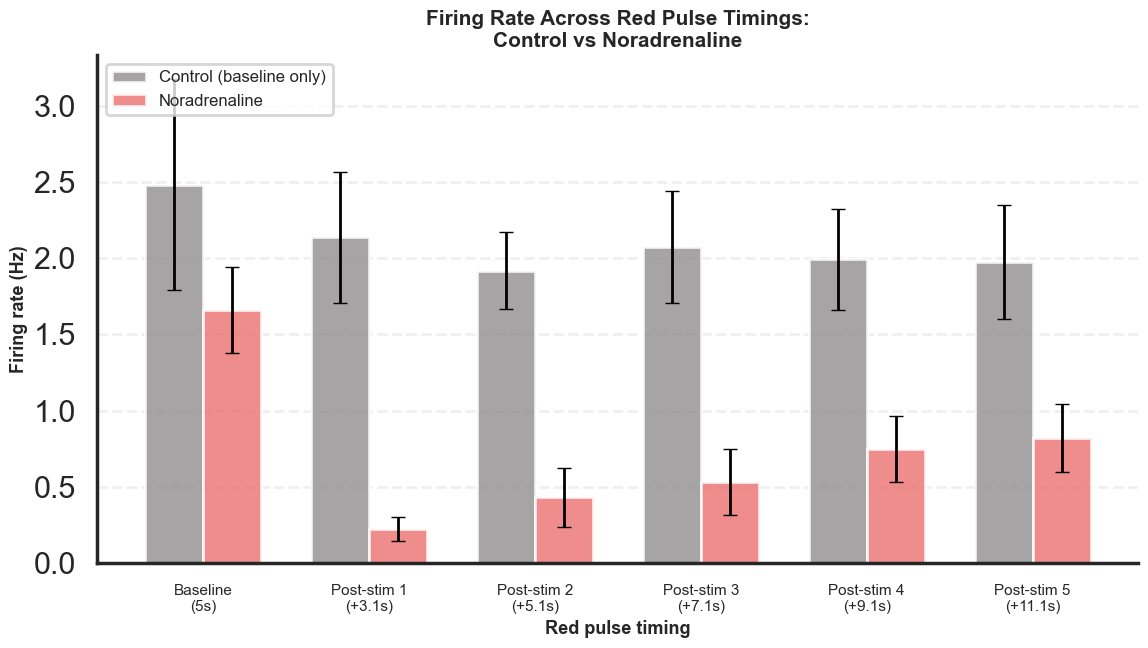

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Settings
EXCEL_PATH = "/Users/rbondare/ephys/results/double_opto_database_V2.xlsx"
SHEET_NAME = "Noradrenaline"
TIME_WINDOW = 0.8  # seconds, time window over which peaks were counted

# Column mapping: pulse timing to column name
PULSE_COLUMNS = {
    "Baseline\n(5s)": "baseline_avg",
    "Post-stim 1\n(+3.1s)": "post_stim_1_avg",
    "Post-stim 2\n(+5.1s)": "post_stim_2_avg",
    "Post-stim 3\n(+7.1s)": "post_stim_3_avg",
    "Post-stim 4\n(+9.1s)": "post_stim_4_avg",
    "Post-stim 5\n(+11.1s)": "post_stim_5_avg",
}


# Load data
df = pd.read_excel(EXCEL_PATH, sheet_name=SHEET_NAME, header=1)

# Separate baseline and NA conditions
baseline_df = df[df['condition'].str.lower() == 'baseline'].copy()
na_df = df[df['condition'].str.lower() == 'noradrenaline'].copy()

print(f"Loaded {len(baseline_df)} baseline cells and {len(na_df)} NA cells")

# Function to process condition data
def process_condition(condition_df, condition_name):
    """Convert peak counts to firing rates and organize by pulse timing."""
    pulse_data = {}
    for pulse_label, column_name in PULSE_COLUMNS.items():
        firing_rates = condition_df[column_name].values / TIME_WINDOW
        firing_rates = firing_rates[~np.isnan(firing_rates)]
        pulse_data[pulse_label] = firing_rates
    return pulse_data

# Process both conditions
baseline_data = process_condition(baseline_df, "Baseline")
na_data = process_condition(na_df, "Noradrenaline")

# Calculate statistics
def calculate_stats(pulse_data):
    """Calculate mean and SEM for each pulse."""
    means = []
    sems = []
    pulse_labels = []
    for label, firing_rates in pulse_data.items():
        means.append(np.mean(firing_rates))
        sems.append(stats.sem(firing_rates))
        pulse_labels.append(label)
    return pulse_labels, np.array(means), np.array(sems)

baseline_labels, baseline_means, baseline_sems = calculate_stats(baseline_data)
na_labels, na_means, na_sems = calculate_stats(na_data)

print("\n" + "="*70)
print("BASELINE RECORDINGS (Control)")
print("="*70)
for label, mean, sem in zip(baseline_labels, baseline_means, baseline_sems):
    print(f"{label:25s}: {mean:6.2f} ± {sem:6.2f} Hz  (n={len(baseline_data[label])} cells)")

print("\n" + "="*70)
print("NORADRENALINE RECORDINGS")
print("="*70)
for label, mean, sem in zip(na_labels, na_means, na_sems):
    print(f"{label:25s}: {mean:6.2f} ± {sem:6.2f} Hz  (n={len(na_data[label])} cells)")

fig, ax = plt.subplots(figsize=(12, 7))

x_pos = np.arange(len(baseline_labels))
width = 0.35

# Plot bars with error bars
ax.bar(x_pos - width/2, baseline_means, width, label='Control (baseline only)',
       color='#908E8E', alpha=0.8, capsize=5)
ax.errorbar(x_pos - width/2, baseline_means, yerr=baseline_sems, fmt='none',
            color='black', capsize=5, linewidth=2, elinewidth=2)

ax.bar(x_pos + width/2, na_means, width, label='Noradrenaline',
       color='#EB6F6F', alpha=0.8, capsize=5)
ax.errorbar(x_pos + width/2, na_means, yerr=na_sems, fmt='none',
            color='black', capsize=5, linewidth=2, elinewidth=2)

ax.set_xlabel('Red pulse timing', fontsize=13, fontweight='bold')
ax.set_ylabel('Firing rate (Hz)', fontsize=13, fontweight='bold')
ax.set_title('Firing Rate Across Red Pulse Timings:\nControl vs Noradrenaline',
             fontsize=15, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(baseline_labels, fontsize=11)
ax.legend(fontsize=12, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()



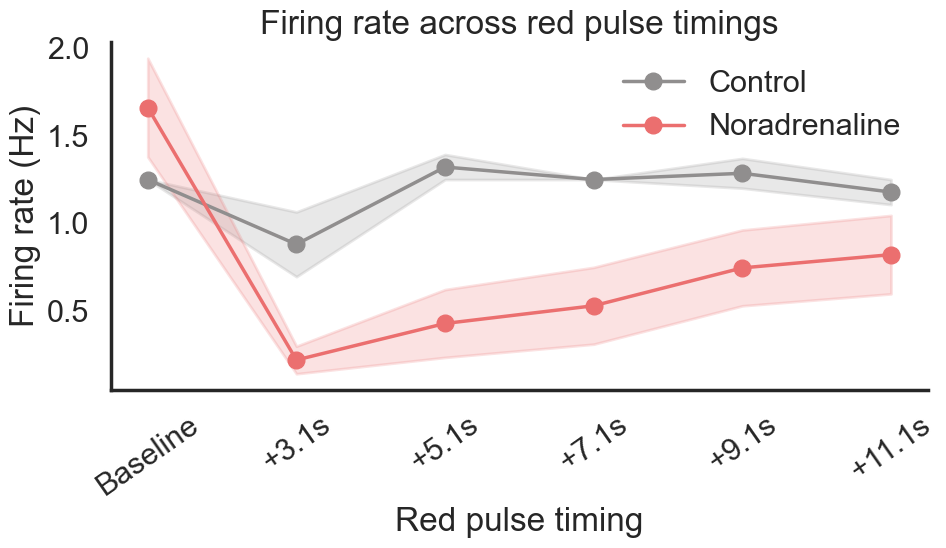

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("poster")
sns.set_style("white")

TIME_WINDOW = 0.8
cols = ["baseline_avg", "post_stim_1_avg", "post_stim_2_avg", "post_stim_3_avg", "post_stim_4_avg", "post_stim_5_avg"]
labels = ["Baseline", "+3.1s", "+5.1s", "+7.1s", "+9.1s", "+11.1s"]
x = np.arange(len(labels))

def load_group(path, sheet_name, condition_tag):
    df = pd.read_excel(path, sheet_name=sheet_name, header=1)
    df = df[df["condition"].astype(str).str.lower() == condition_tag].copy()
    rates = df[cols].apply(pd.to_numeric, errors="coerce") / TIME_WINDOW
    return rates.mean(), rates.sem()

control_mean, control_sem = load_group("/Users/rbondare/ephys/results/double_opto_database_V3.xlsx", "Control", "blue light")
na_mean, na_sem = load_group("/Users/rbondare/ephys/results/double_opto_database_V2.xlsx", "Noradrenaline", "noradrenaline")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x, control_mean, marker="o", lw=2.5, color="#908E8E", label="Control")
ax.fill_between(x, control_mean - control_sem, control_mean + control_sem, color="#908E8E", alpha=0.2)
ax.plot(x, na_mean, marker="o", lw=2.5, color="#EB6F6F", label="Noradrenaline")
ax.fill_between(x, na_mean - na_sem, na_mean + na_sem, color="#EB6F6F", alpha=0.2)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=35)
ax.set_xlabel("Red pulse timing")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("Firing rate across red pulse timings")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

### NA-timing trajectory: style comparison grid

Full time-course (Baseline + Post-stim 1-5) for Control (blue light only) vs
Noradrenaline, both sourced from `double_opto_database_V3.xlsx` (sheets
`Control` and `Noradrenaline`). Rows compare two different sources for the
"Baseline" (x=0) point per cell:
- **pulse**: the red pulse within the same stimulated recording, just before blue light
- **recording**: the separate, dedicated no-light recording for that same cell

Columns compare three visual styles (line+SEM band, grouped bars, per-cell
points) so the best one for the poster can be picked. `Exclude`-flagged rows
are dropped before aggregating. Note: this still uses `time_window = 0.8`
uniformly for all 6 positions even though the Baseline window is actually
0.9 s wide (see cell 6) — that fix is deferred to a later pass.

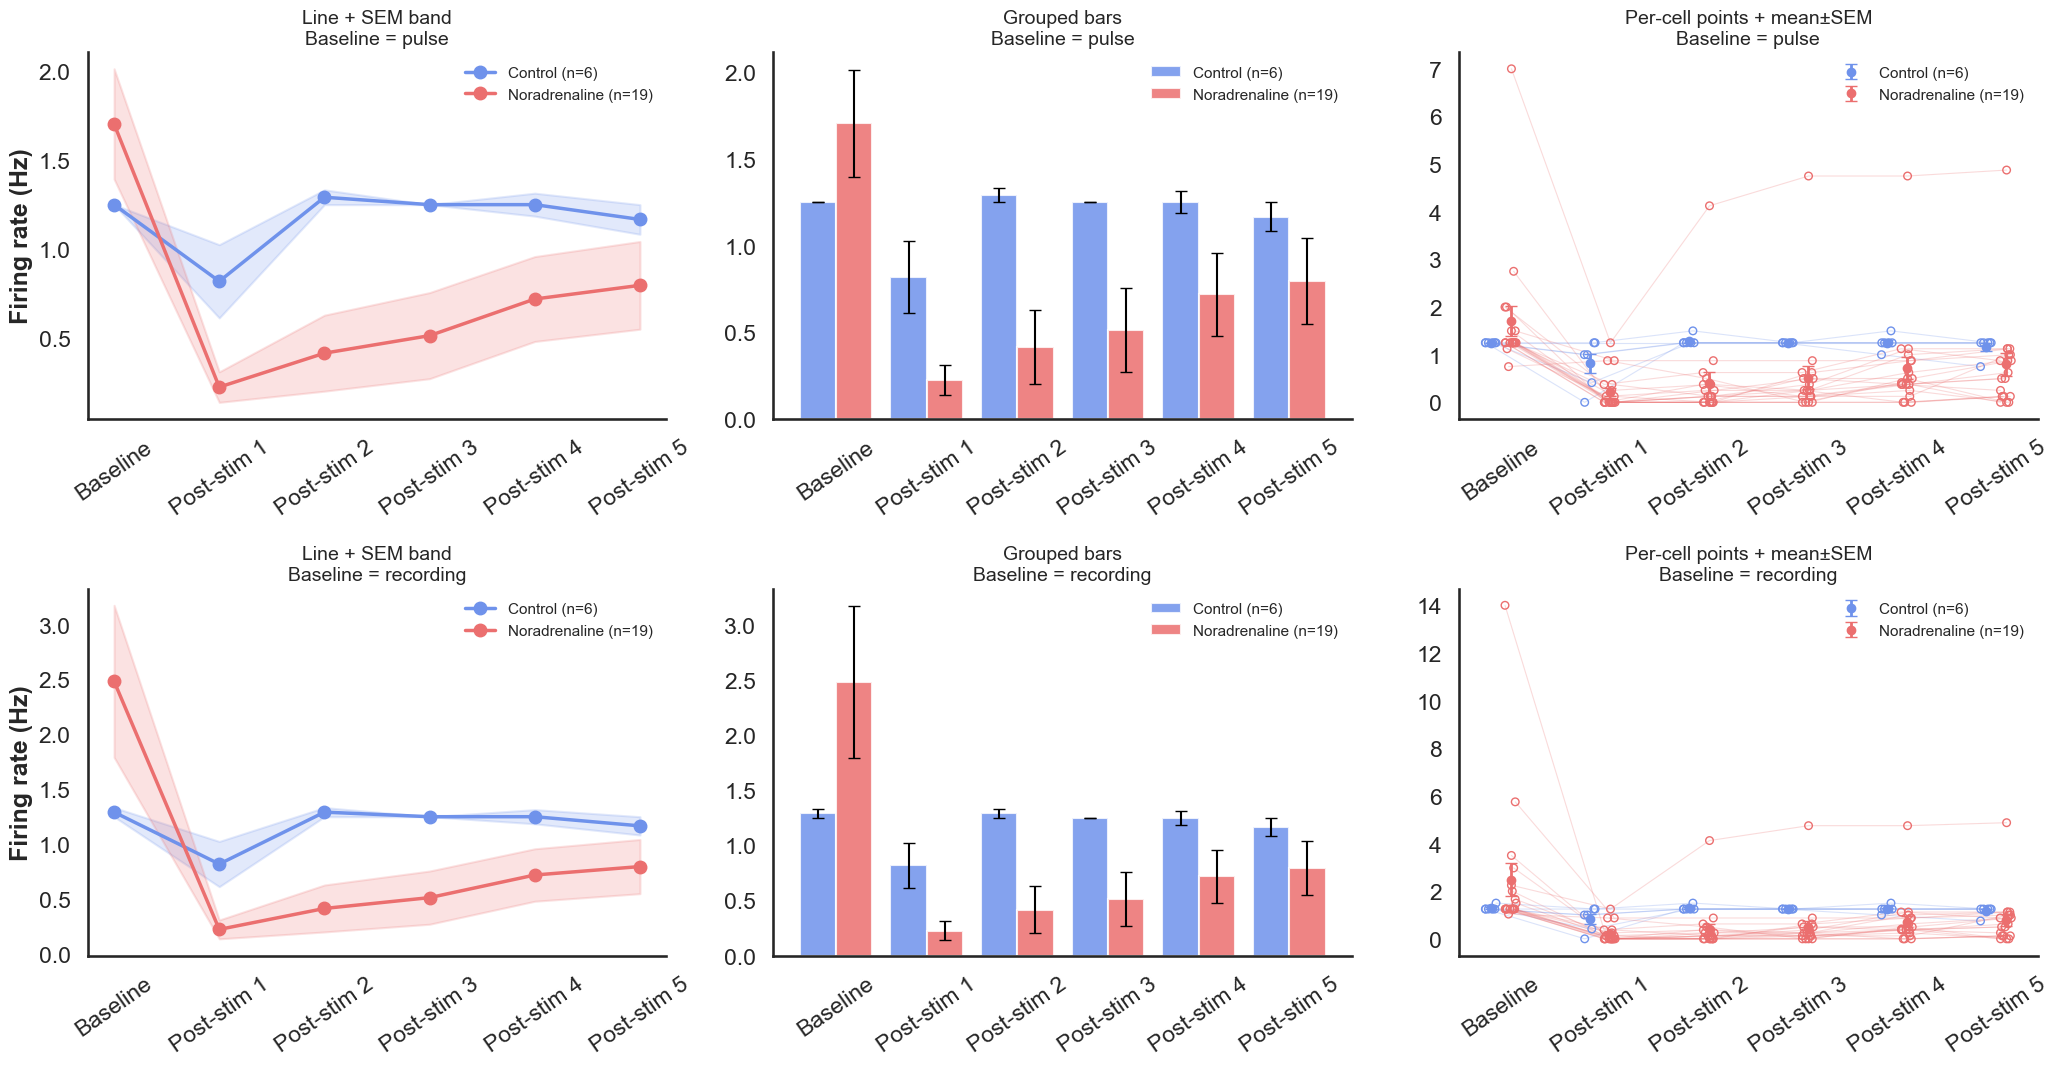

In [4]:
"""NA-timing trajectory: Baseline-pulse vs Baseline-recording, multiple plot styles"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_context("talk")
sns.set_style("white")

# =============================================================================
# USER SETTINGS
# =============================================================================

RESULTS_TABLE_PATH = "/Users/rbondare/ephys/results/double_opto_database_V3.xlsx"

# time window (s) over which counts were measured.
# NOTE: the Baseline window is actually 0.9 s wide (5.0-5.9 s, see cell 6)
# while post-stim windows are 0.8 s wide (X.1-X.9 s) -- this is left as a
# known issue and deferred to a later pass, so everything below uses 0.8
# uniformly to stay consistent with cells 7/9/11/12/13.
TIME_WINDOW = 0.8

POSTSTIM_COLS = ["post_stim_1_avg", "post_stim_2_avg", "post_stim_3_avg", "post_stim_4_avg", "post_stim_5_avg"]
X_LABELS = ["Baseline", "Post-stim 1", "Post-stim 2", "Post-stim 3", "Post-stim 4", "Post-stim 5"]

DATASETS = {
    "Control": {"sheet_name": "Control", "stim_condition": "blue light", "color": "#6F92EB"},
    "Noradrenaline": {"sheet_name": "Noradrenaline", "stim_condition": "noradrenaline", "color": "#EB6F6F"},
}

# =============================================================================
# DATA PREPARATION
# =============================================================================

def load_trajectory(sheet_name, stim_condition, baseline_source):
    """Per-cell firing-rate trajectory (Hz) across Baseline + Post-stim 1-5.

    baseline_source:
      "pulse"     -> Baseline point = the stimulated row's own baseline_avg
                     (red pulse immediately before blue light, same recording)
      "recording" -> Baseline point = the separate condition=="baseline" row's
                     baseline_avg (a dedicated no-light recording for the same cell)
    """
    df = pd.read_excel(RESULTS_TABLE_PATH, sheet_name=sheet_name, header=1)

    # drop rows explicitly flagged for exclusion before any aggregation
    exclude_mask = df["comment"].astype(str).str.contains("Exclude", case=False, na=False)
    df = df.loc[~exclude_mask].copy()

    cond = df["condition"].astype(str).str.strip().str.lower()

    stim_rows = df[cond == stim_condition].copy()
    stim_agg = stim_rows.groupby("ID")[["baseline_avg"] + POSTSTIM_COLS].mean()

    if baseline_source == "pulse":
        baseline_vals = stim_agg["baseline_avg"]
    else:
        baseline_rows = df[cond == "baseline"].copy()
        baseline_vals = baseline_rows.groupby("ID")["baseline_avg"].mean()

    trajectory = stim_agg[POSTSTIM_COLS].copy()
    trajectory.insert(0, "baseline_avg", baseline_vals)
    trajectory = trajectory.dropna()

    trajectory = trajectory / TIME_WINDOW
    trajectory.columns = X_LABELS
    return trajectory


def trajectory_mean_sem(trajectory):
    return trajectory.mean(), trajectory.sem()


# =============================================================================
# PLOT STYLE FUNCTIONS
# =============================================================================

def plot_line_band(ax, trajectories):
    x = np.arange(len(X_LABELS))
    for name, traj in trajectories.items():
        color = DATASETS[name]["color"]
        mean, sem = trajectory_mean_sem(traj)
        ax.plot(x, mean.values, marker="o", lw=2.5, color=color, label=f"{name} (n={len(traj)})")
        ax.fill_between(x, mean.values - sem.values, mean.values + sem.values, color=color, alpha=0.2)
    ax.set_xticks(x)
    ax.set_xticklabels(X_LABELS, rotation=35)
    ax.legend(frameon=False, fontsize=11)


def plot_grouped_bars(ax, trajectories):
    x = np.arange(len(X_LABELS))
    n_groups = len(trajectories)
    width = 0.8 / n_groups
    for i, (name, traj) in enumerate(trajectories.items()):
        color = DATASETS[name]["color"]
        mean, sem = trajectory_mean_sem(traj)
        offset = (i - (n_groups - 1) / 2) * width
        ax.bar(x + offset, mean.values, width, color=color, alpha=0.85, label=f"{name} (n={len(traj)})")
        ax.errorbar(x + offset, mean.values, yerr=sem.values, fmt="none", color="black", capsize=4, elinewidth=1.5)
    ax.set_xticks(x)
    ax.set_xticklabels(X_LABELS, rotation=35)
    ax.legend(frameon=False, fontsize=11)


def plot_percell_points(ax, trajectories):
    x = np.arange(len(X_LABELS))
    rng = np.random.default_rng(0)
    jitter = 0.06
    n_groups = len(trajectories)
    for i, (name, traj) in enumerate(trajectories.items()):
        color = DATASETS[name]["color"]
        offset = (i - (n_groups - 1) / 2) * 0.2
        for _, row in traj.iterrows():
            dx = offset + rng.uniform(-jitter, jitter)
            ax.plot(x + dx, row.values, color=color, alpha=0.25, linewidth=0.8, zorder=2)
            ax.scatter(x + dx, row.values, facecolors="none", edgecolors=color, s=30, linewidths=1.0, zorder=3)
        mean, sem = trajectory_mean_sem(traj)
        ax.errorbar(x + offset, mean.values, yerr=sem.values, fmt="o", color=color, ecolor=color,
                     capsize=4, elinewidth=2, markersize=6, zorder=4, label=f"{name} (n={len(traj)})")
    ax.set_xticks(x)
    ax.set_xticklabels(X_LABELS, rotation=35)
    ax.legend(frameon=False, fontsize=11)


# =============================================================================
# BUILD GRID: rows = baseline source, columns = plot style
# Each panel gets its own y-axis (no sharey) so an outlier cell in one
# panel doesn't compress the visible range in the others.
# =============================================================================

baseline_sources = ["pulse", "recording"]
styles = [
    ("Line + SEM band", plot_line_band),
    ("Grouped bars", plot_grouped_bars),
    ("Per-cell points + mean±SEM", plot_percell_points),
]

fig, axes = plt.subplots(2, 3, figsize=(21, 11))

for row, baseline_source in enumerate(baseline_sources):
    trajectories = {
        name: load_trajectory(cfg["sheet_name"], cfg["stim_condition"], baseline_source)
        for name, cfg in DATASETS.items()
    }
    for col, (style_name, style_fn) in enumerate(styles):
        ax = axes[row, col]
        style_fn(ax, trajectories)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        if col == 0:
            ax.set_ylabel("Firing rate (Hz)", fontweight="bold")
        ax.set_title(f"{style_name}\nBaseline = {baseline_source}", fontsize=14)

plt.tight_layout()
plt.show()


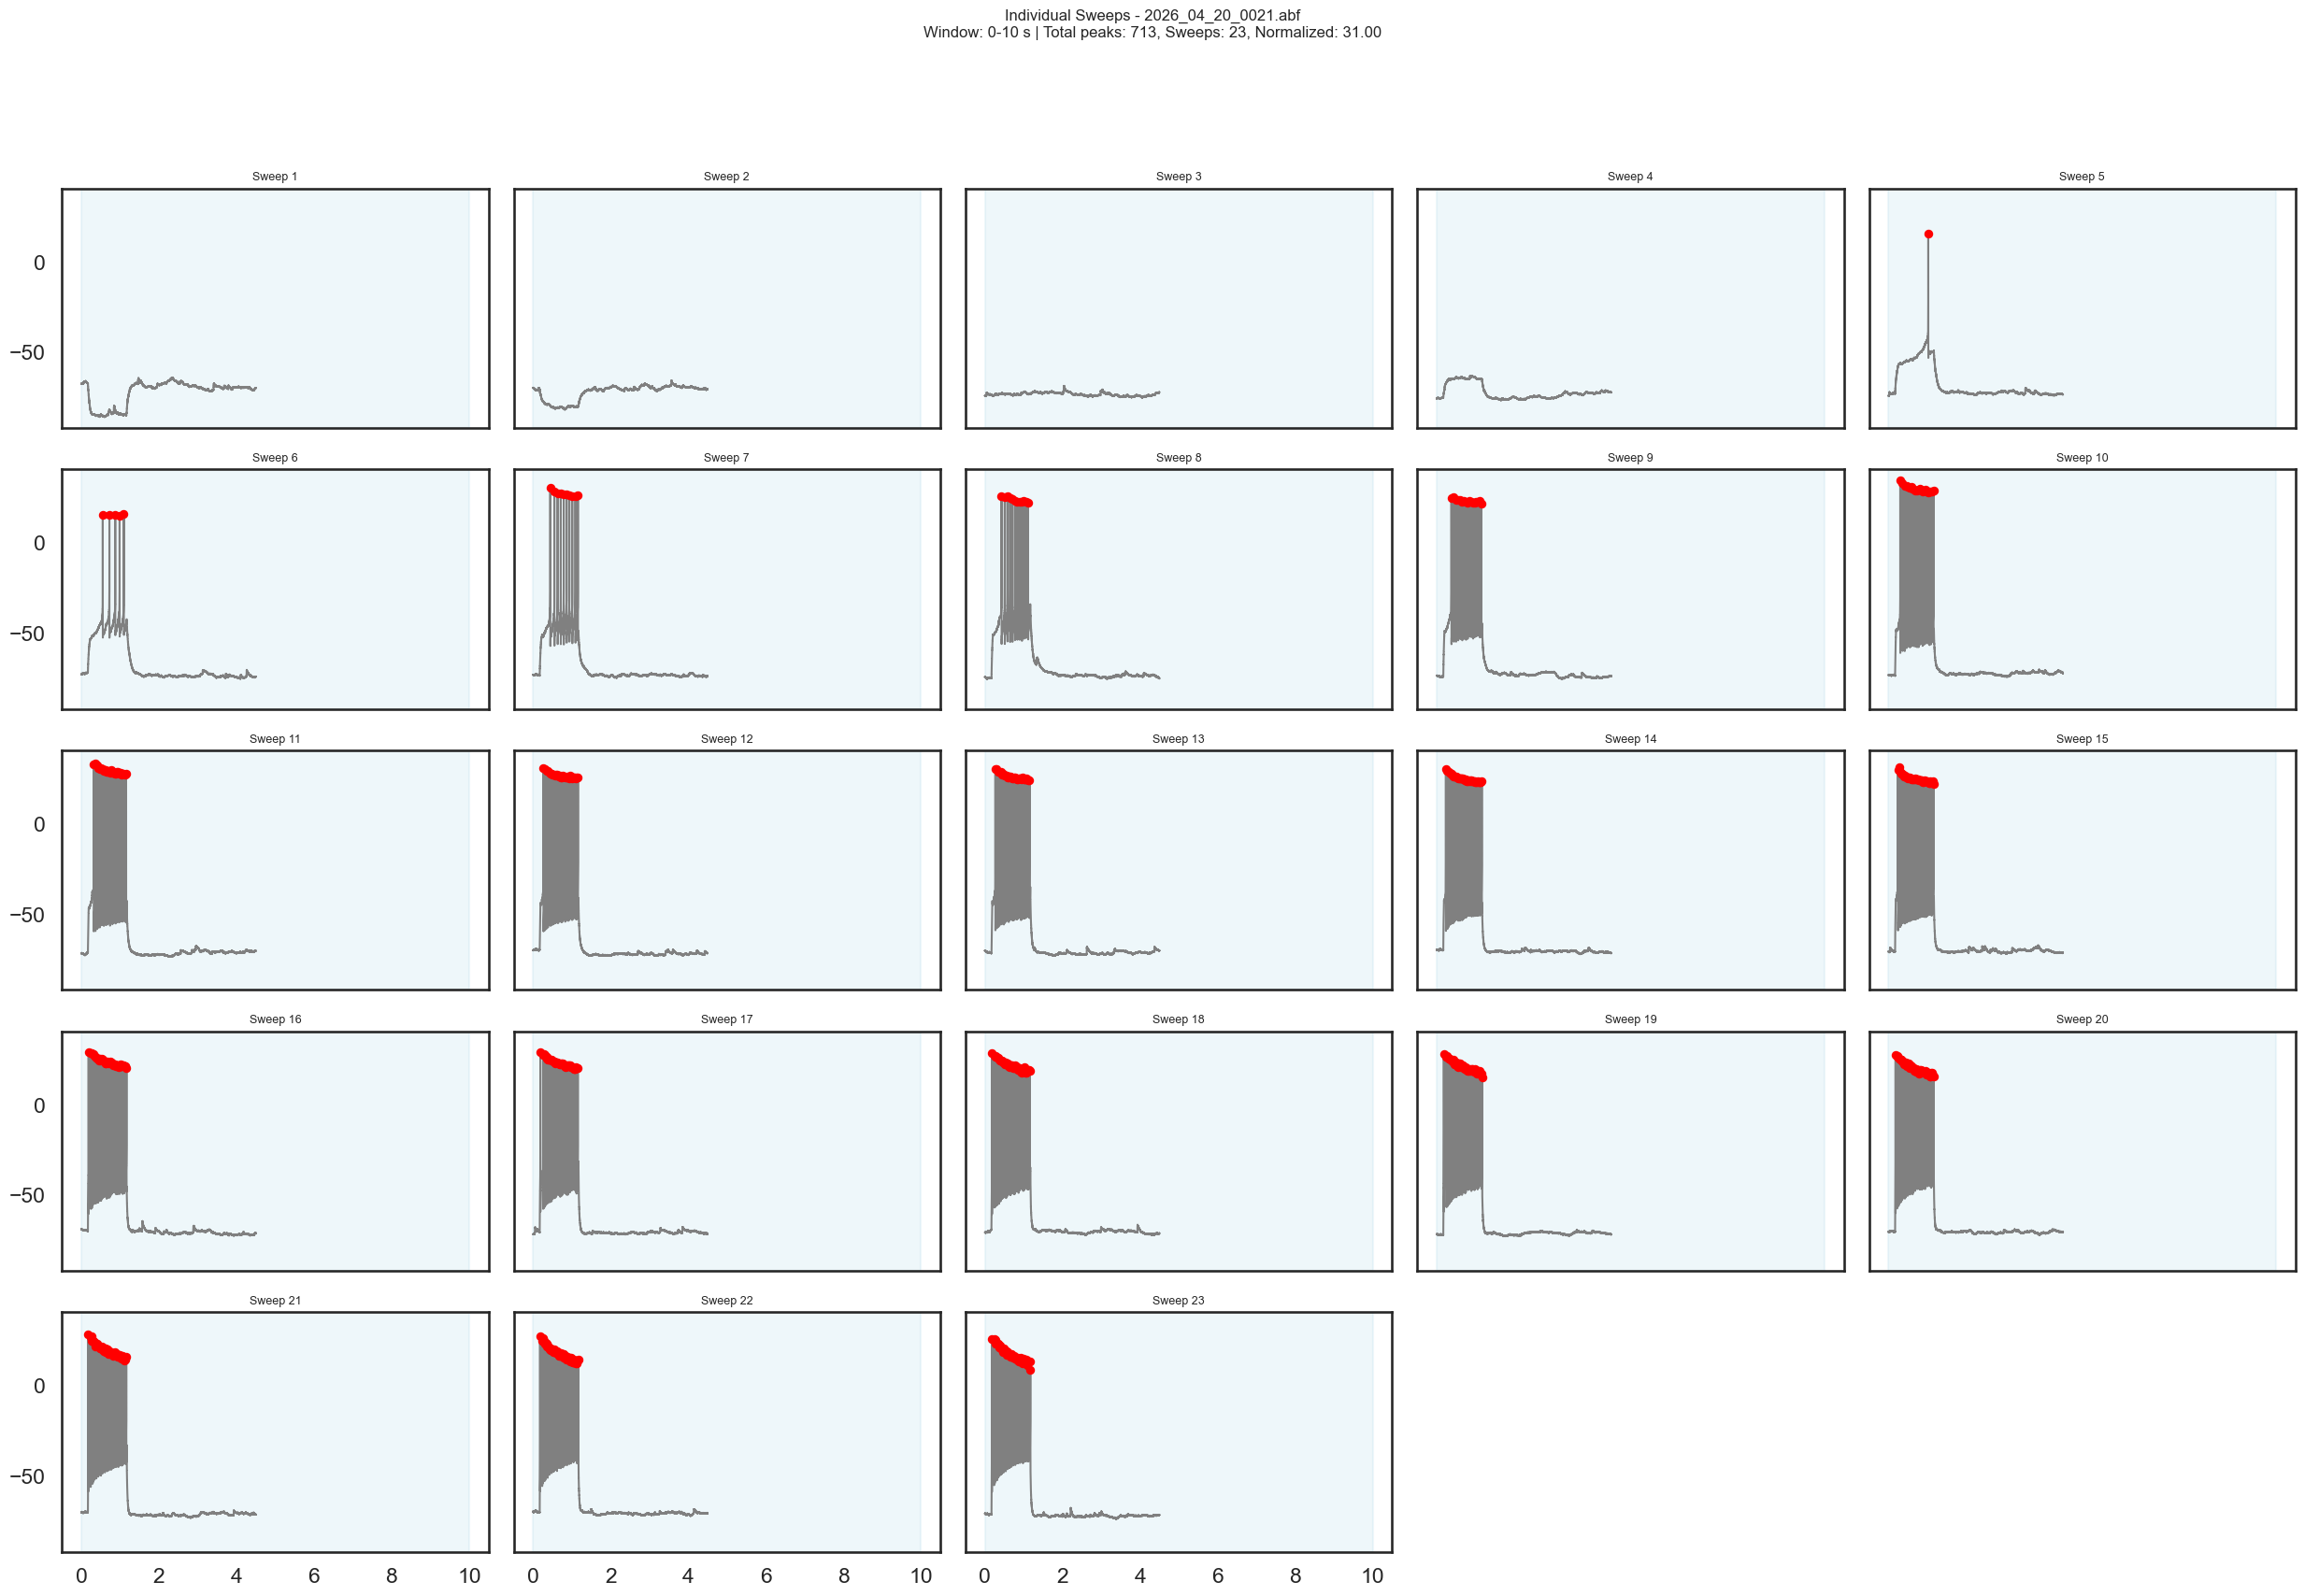

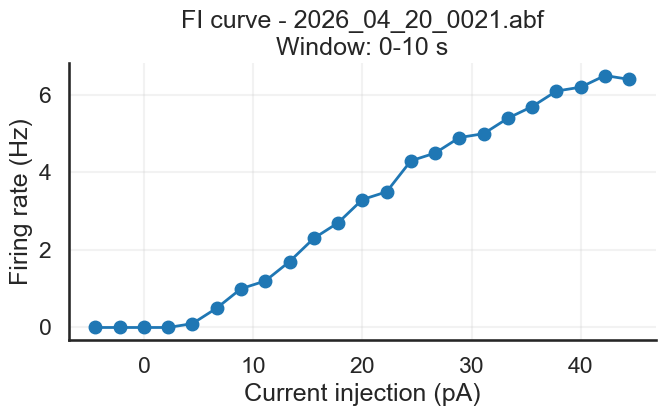

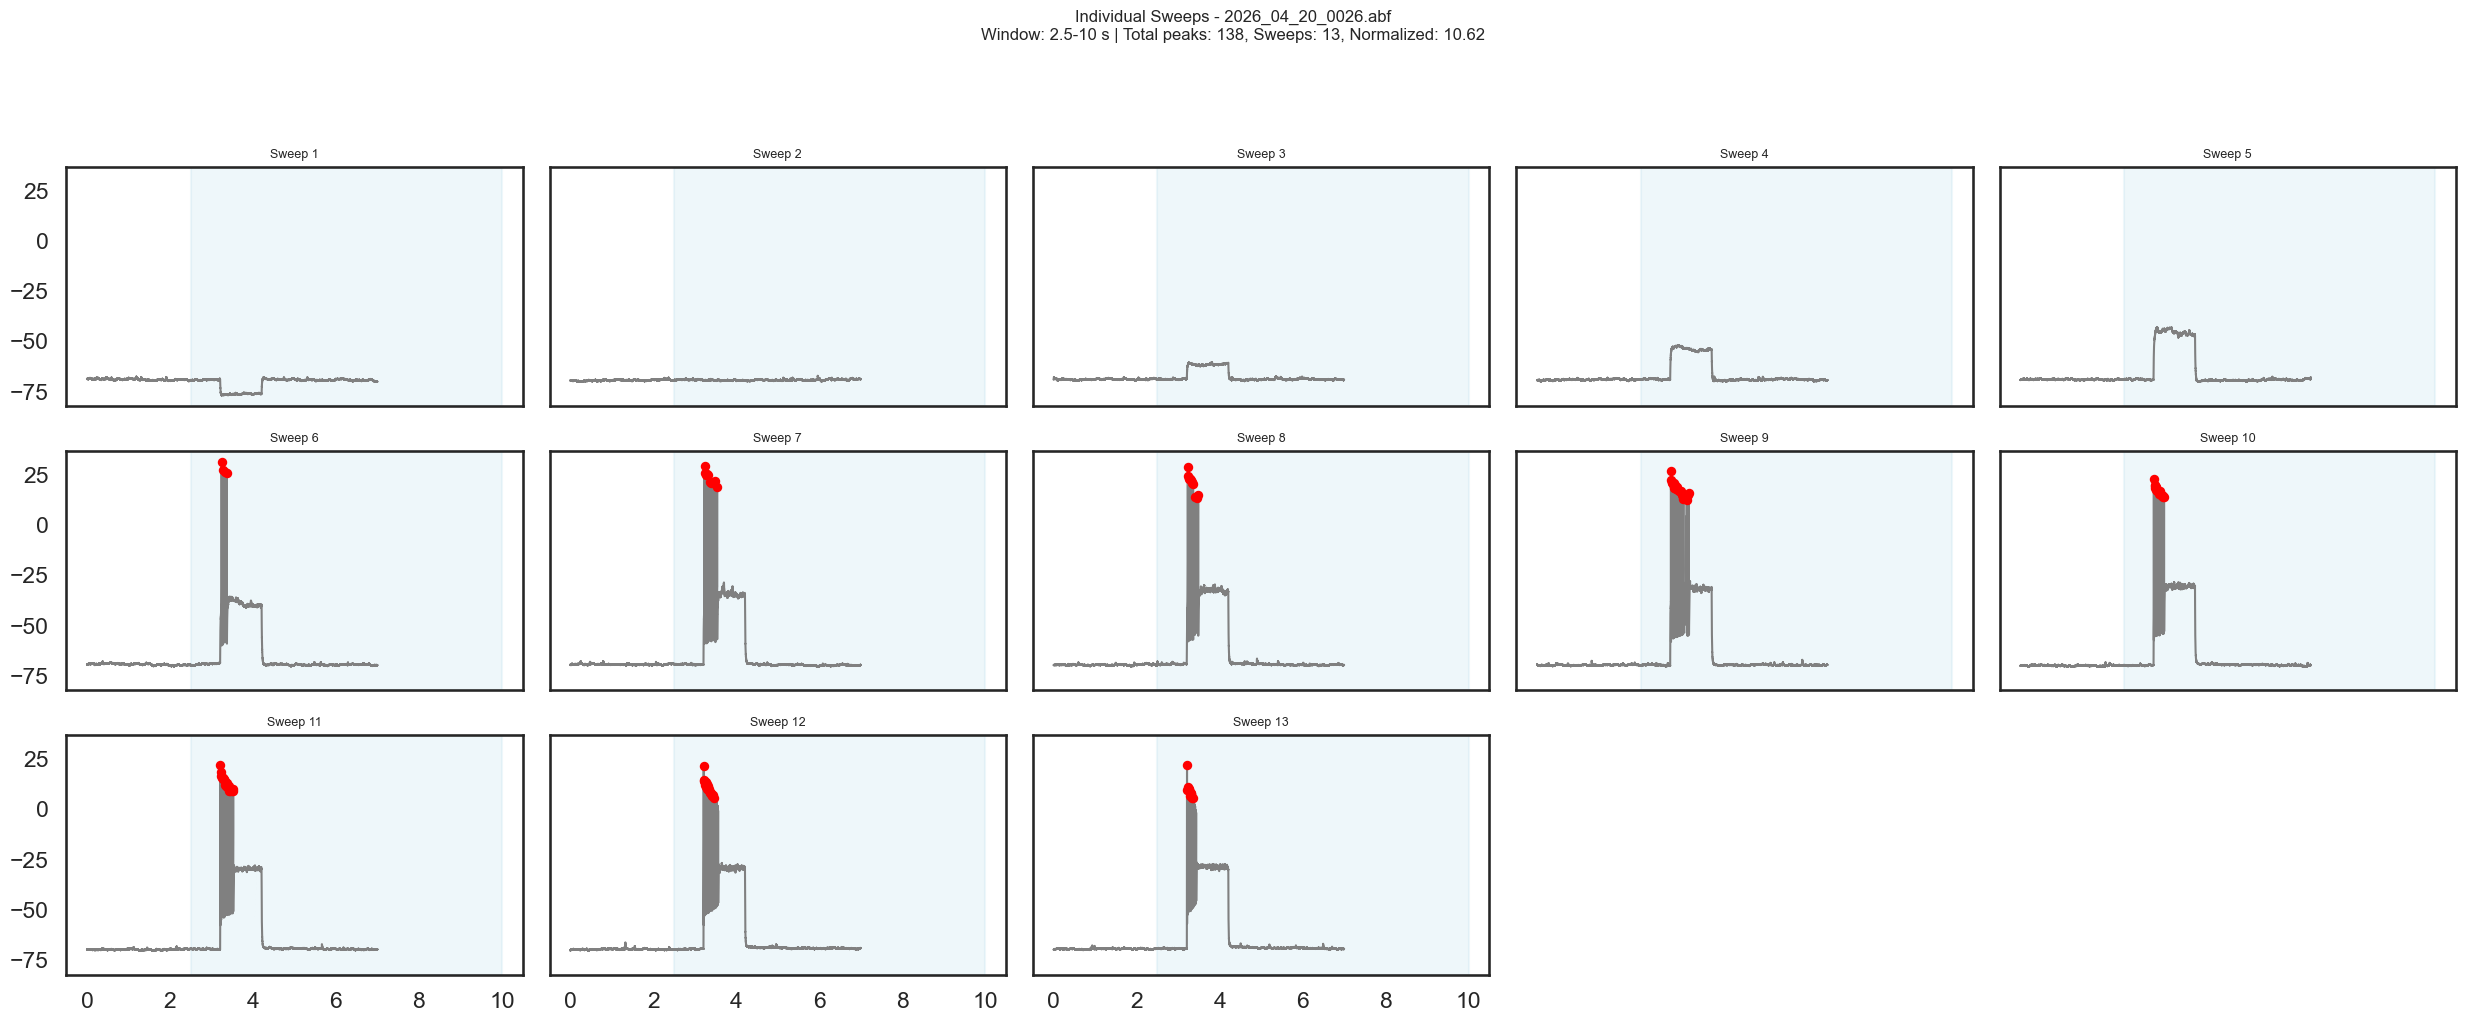

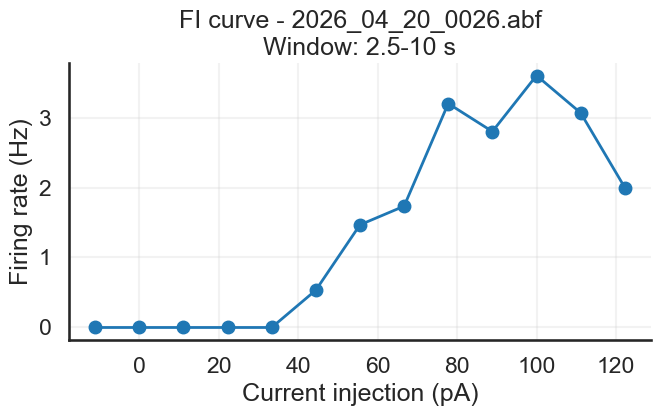

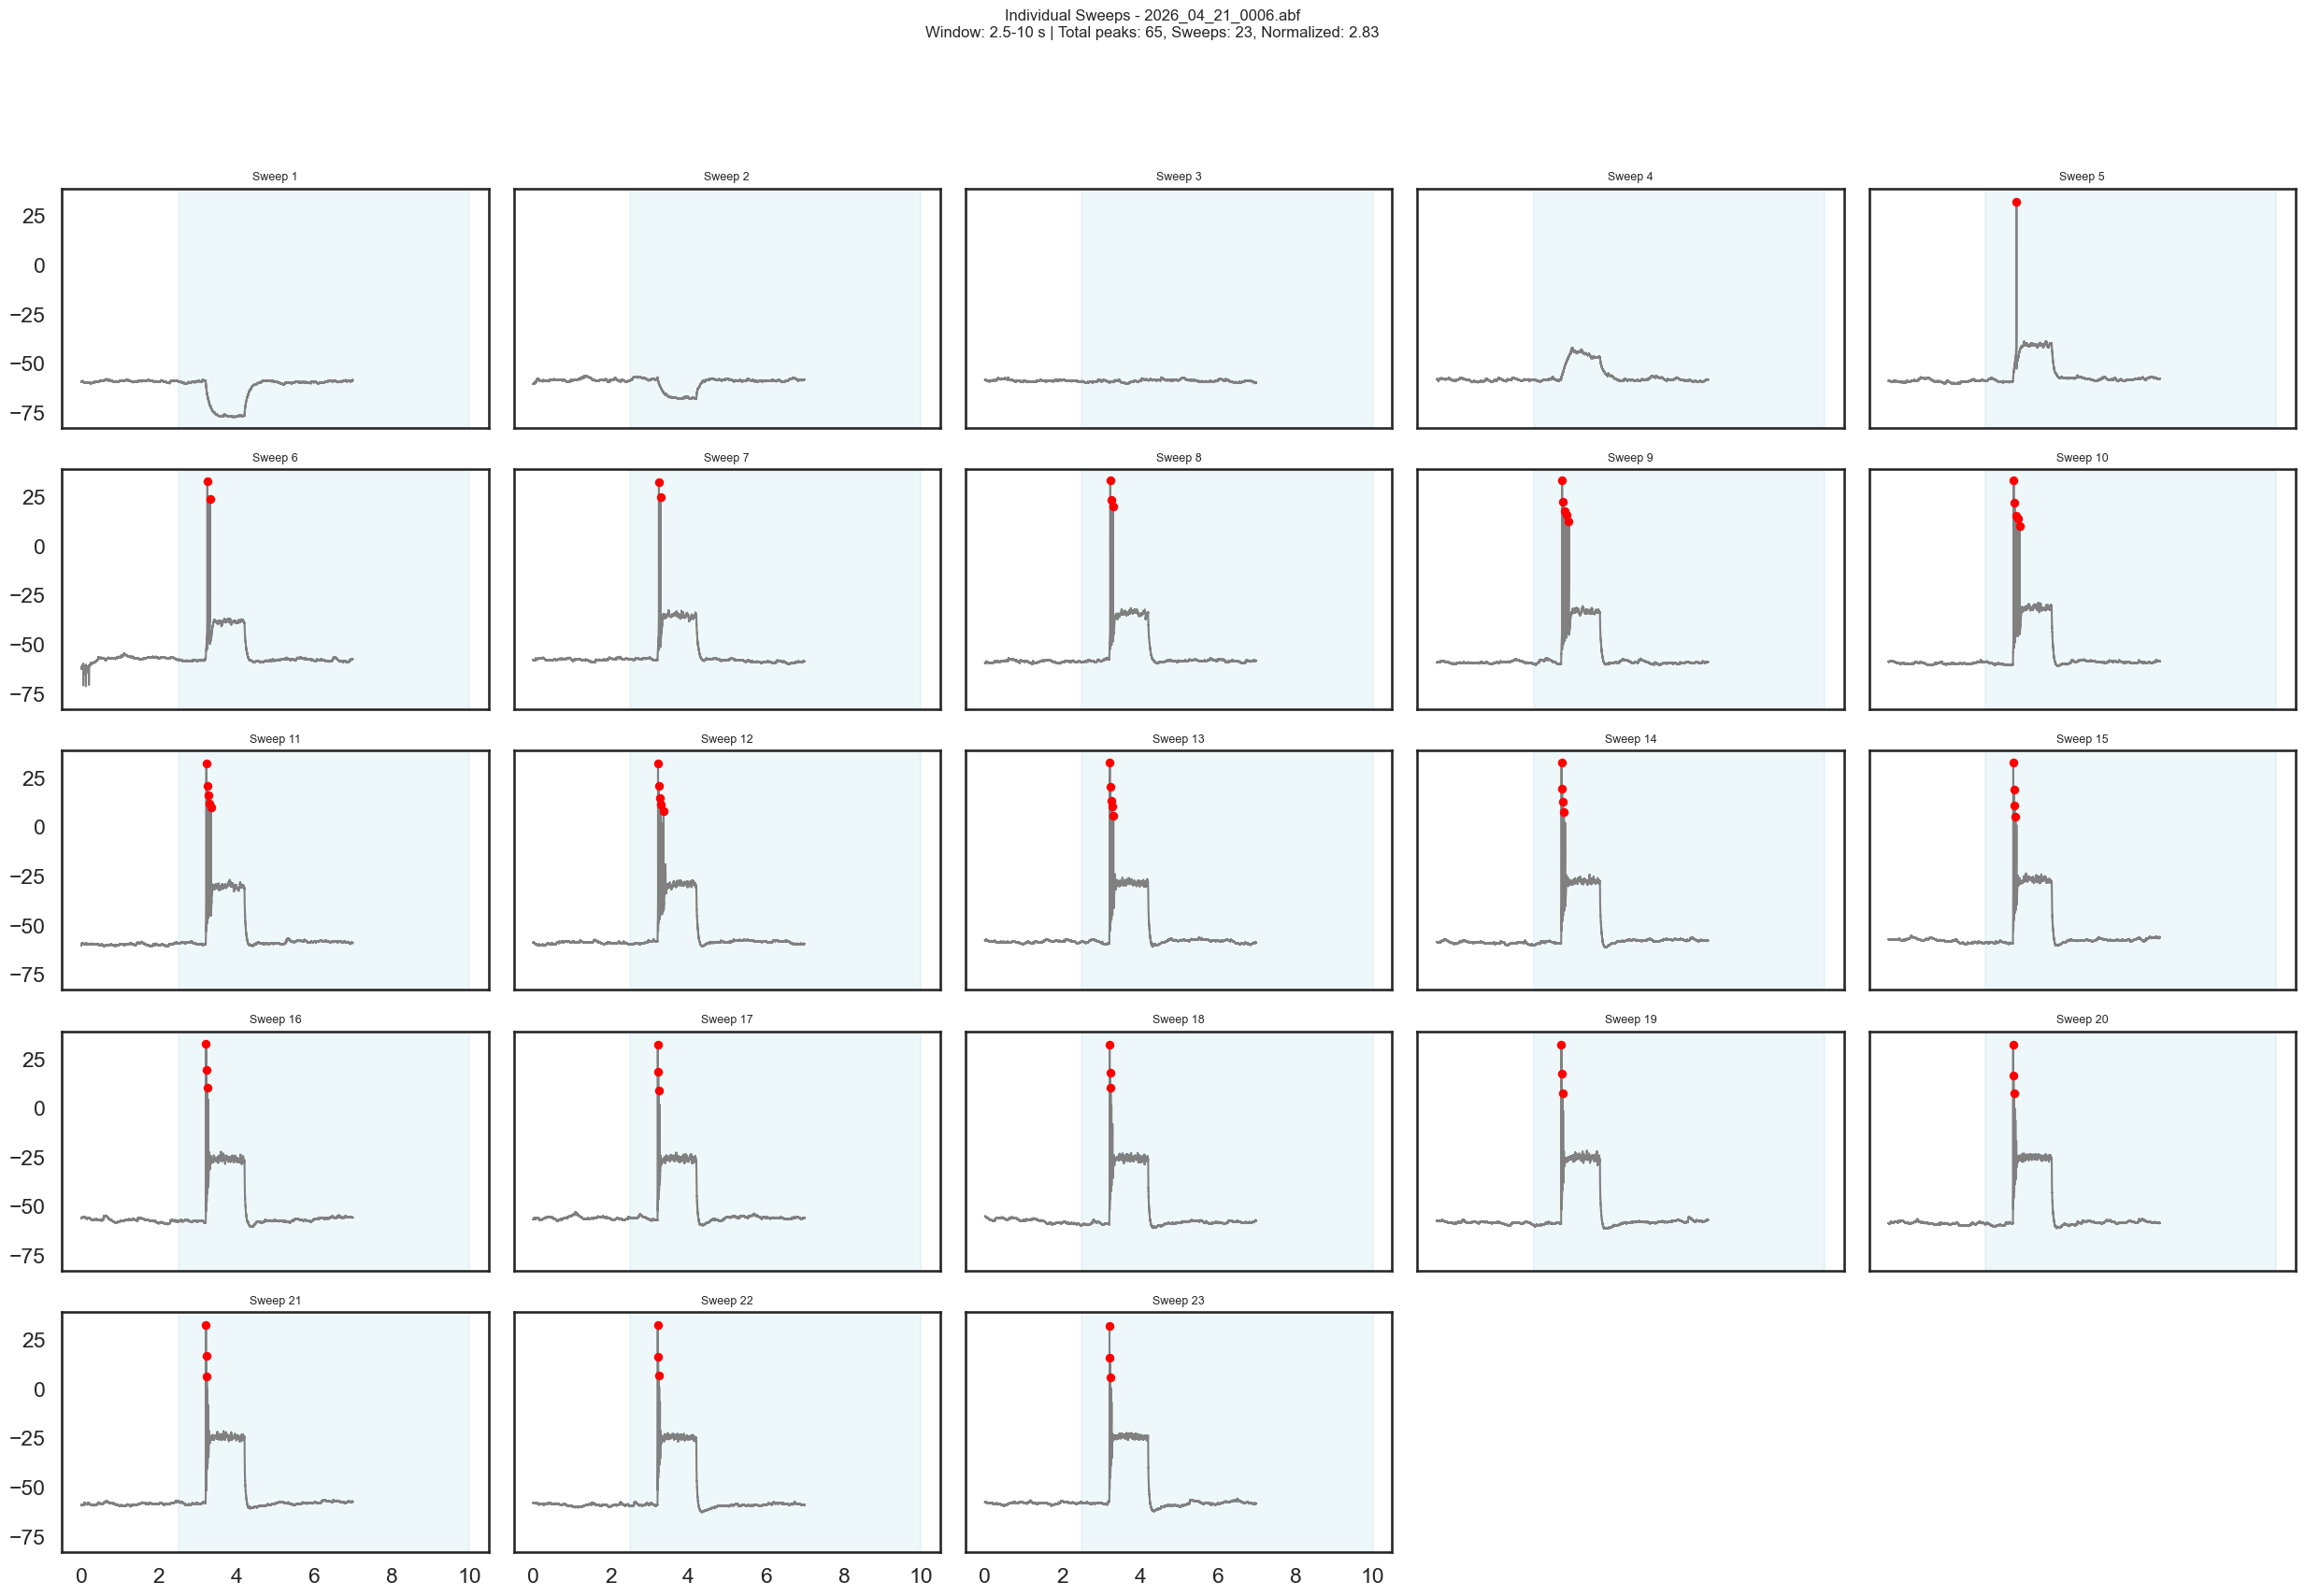

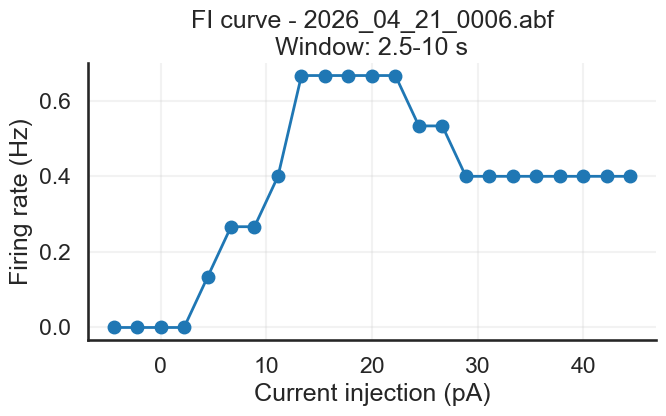

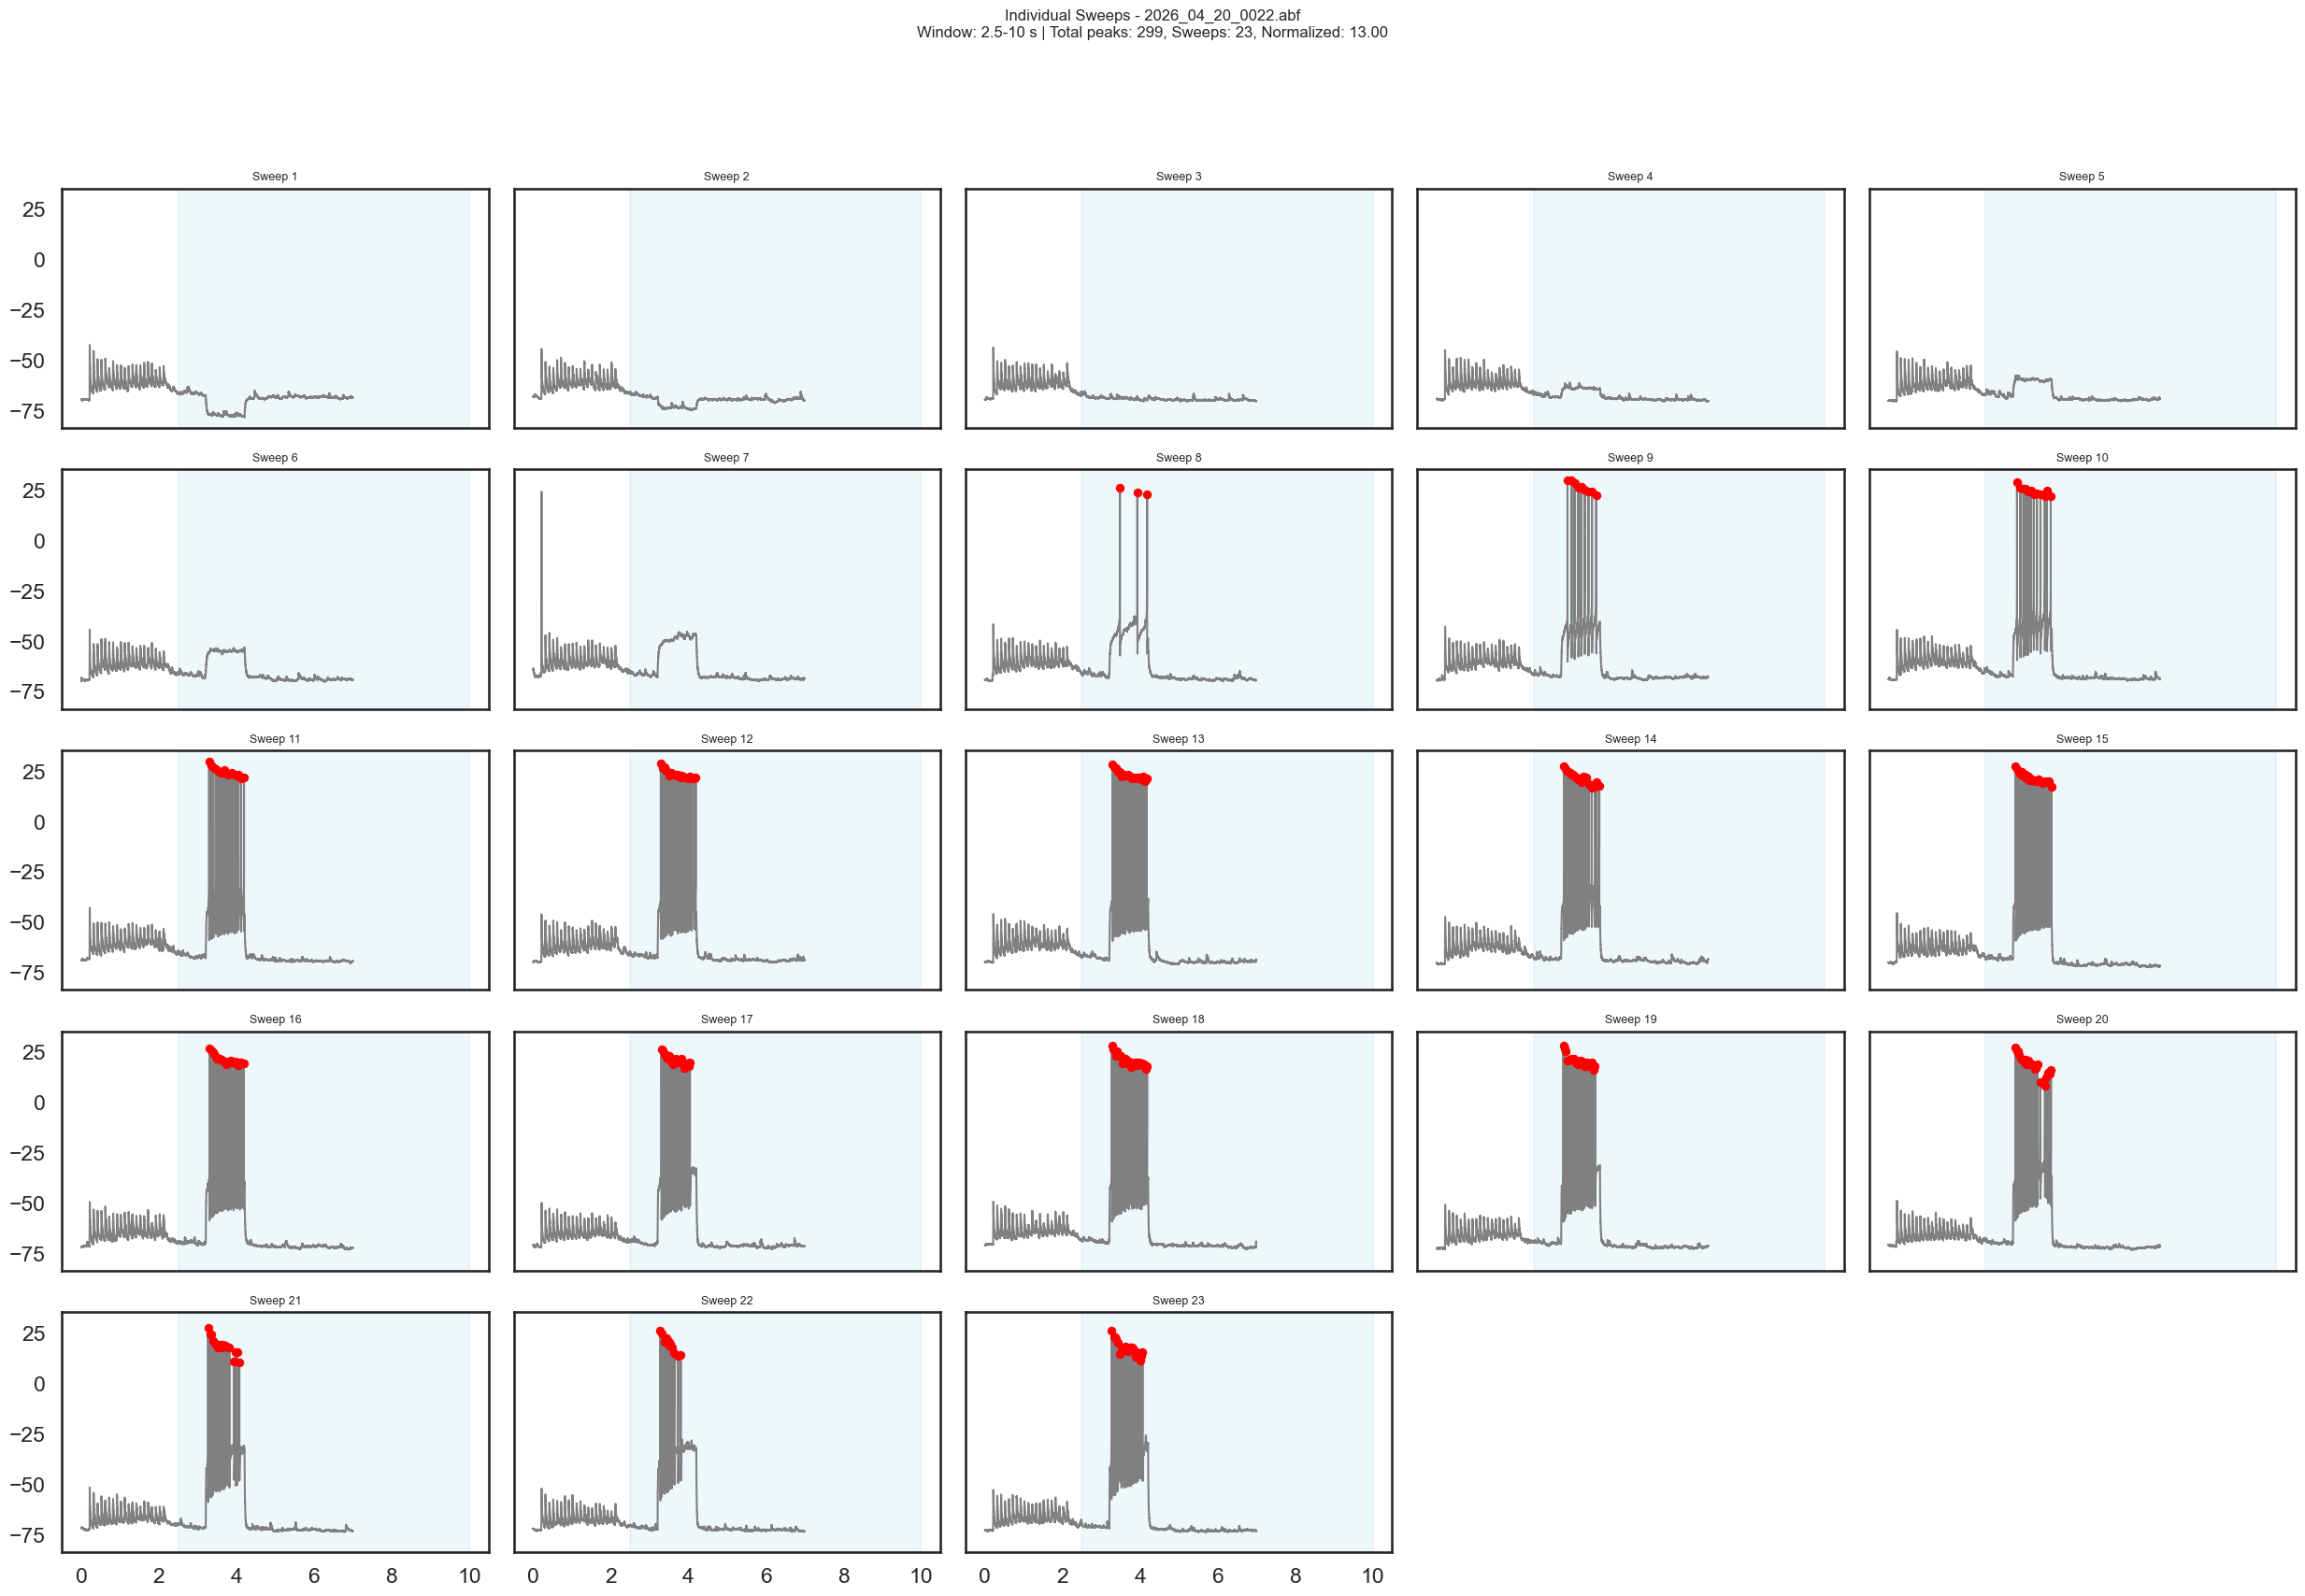

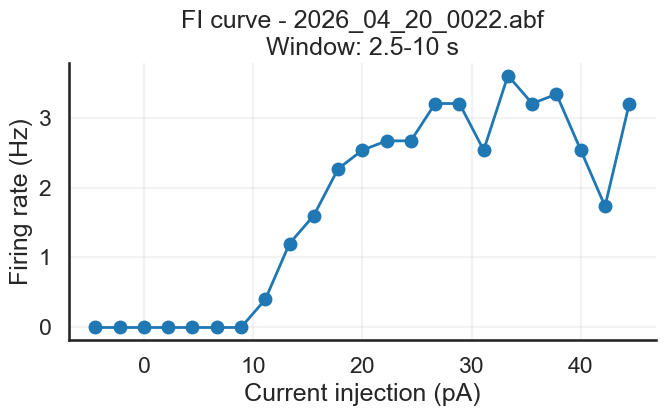

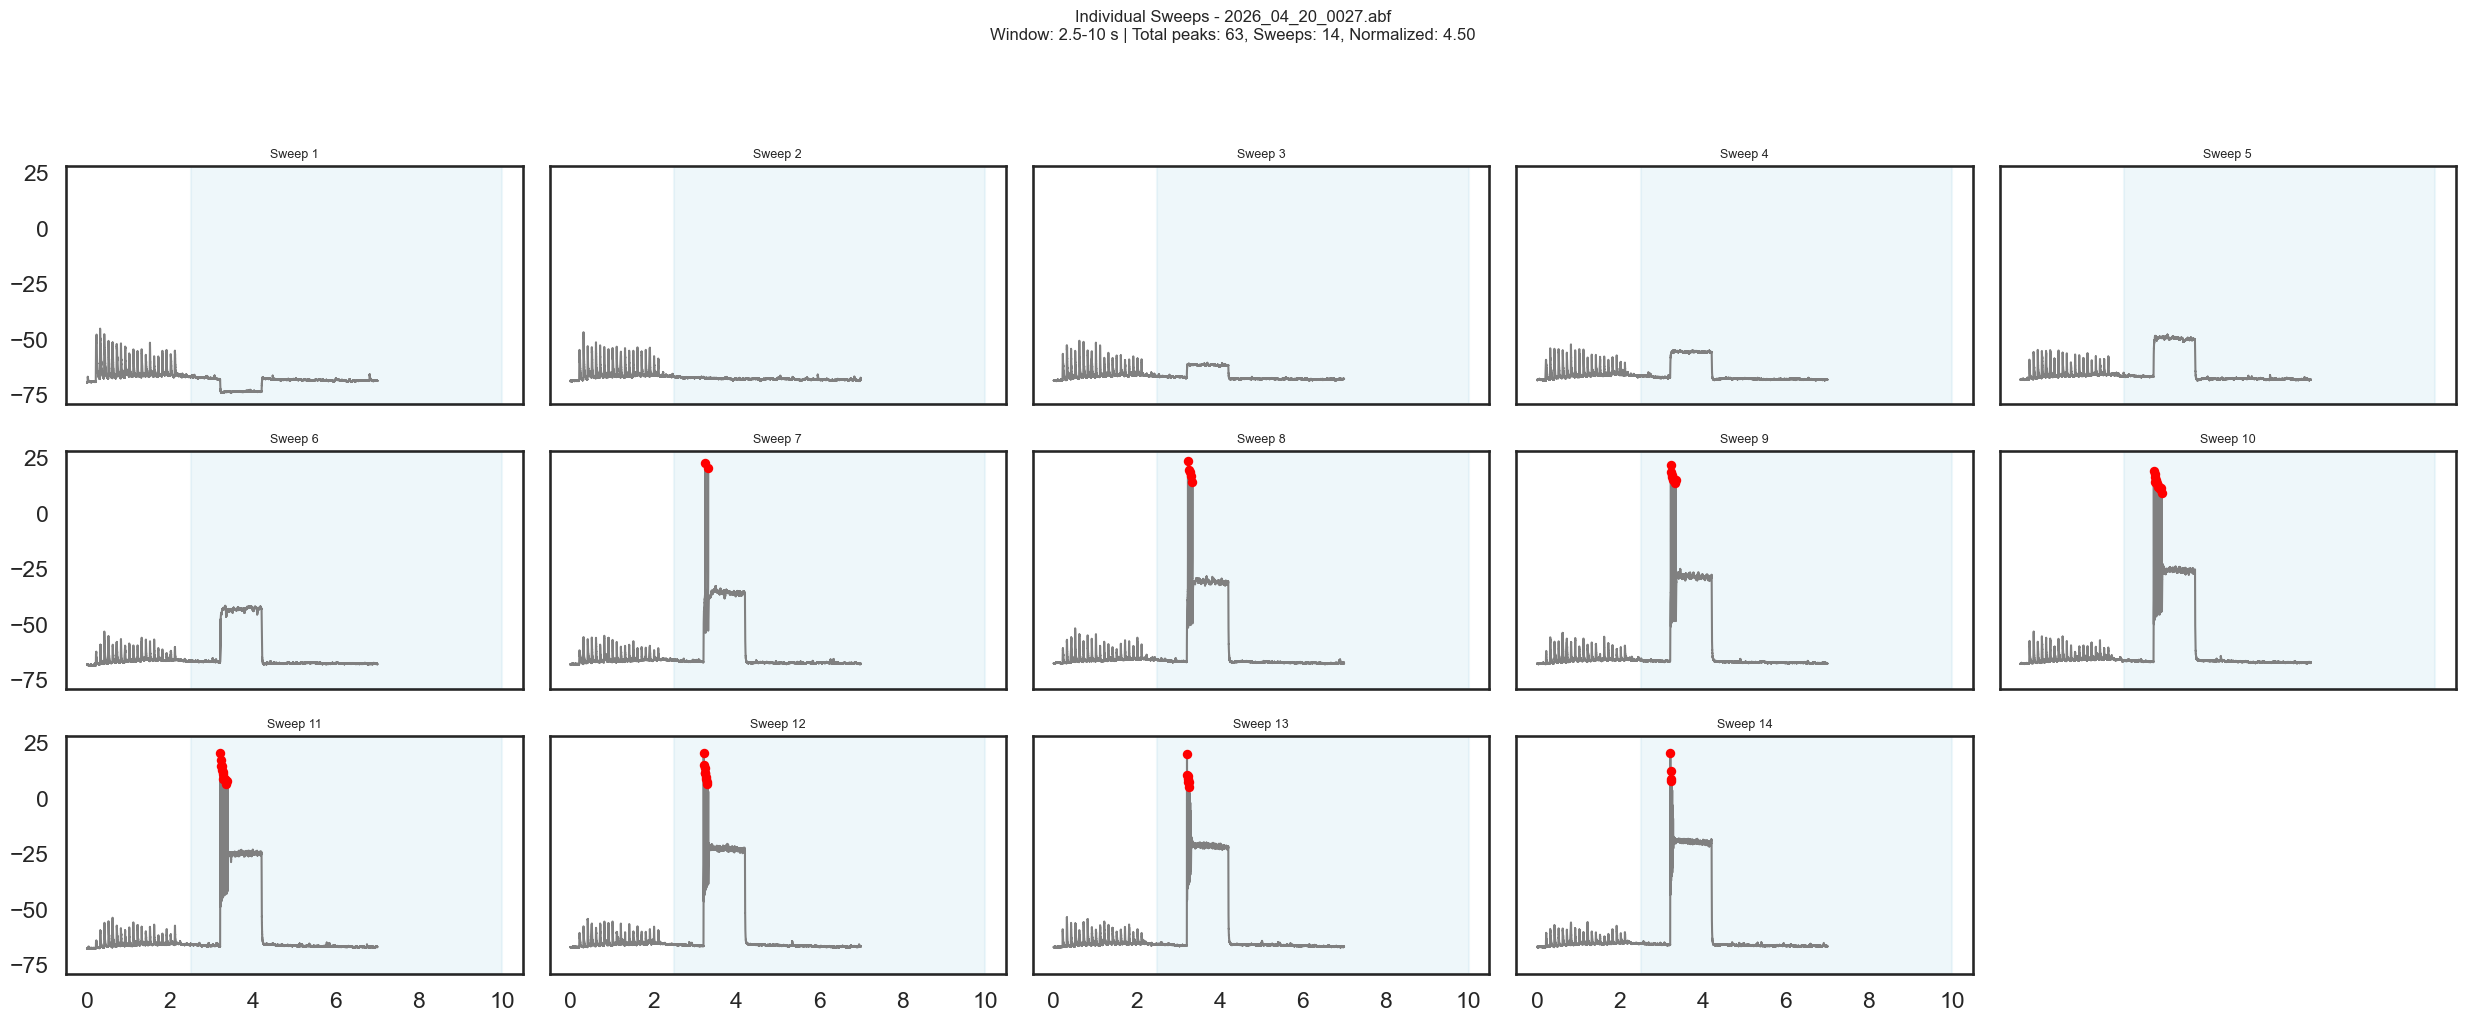

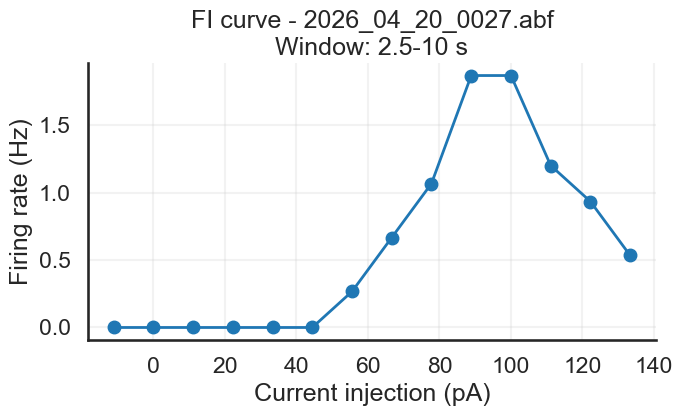

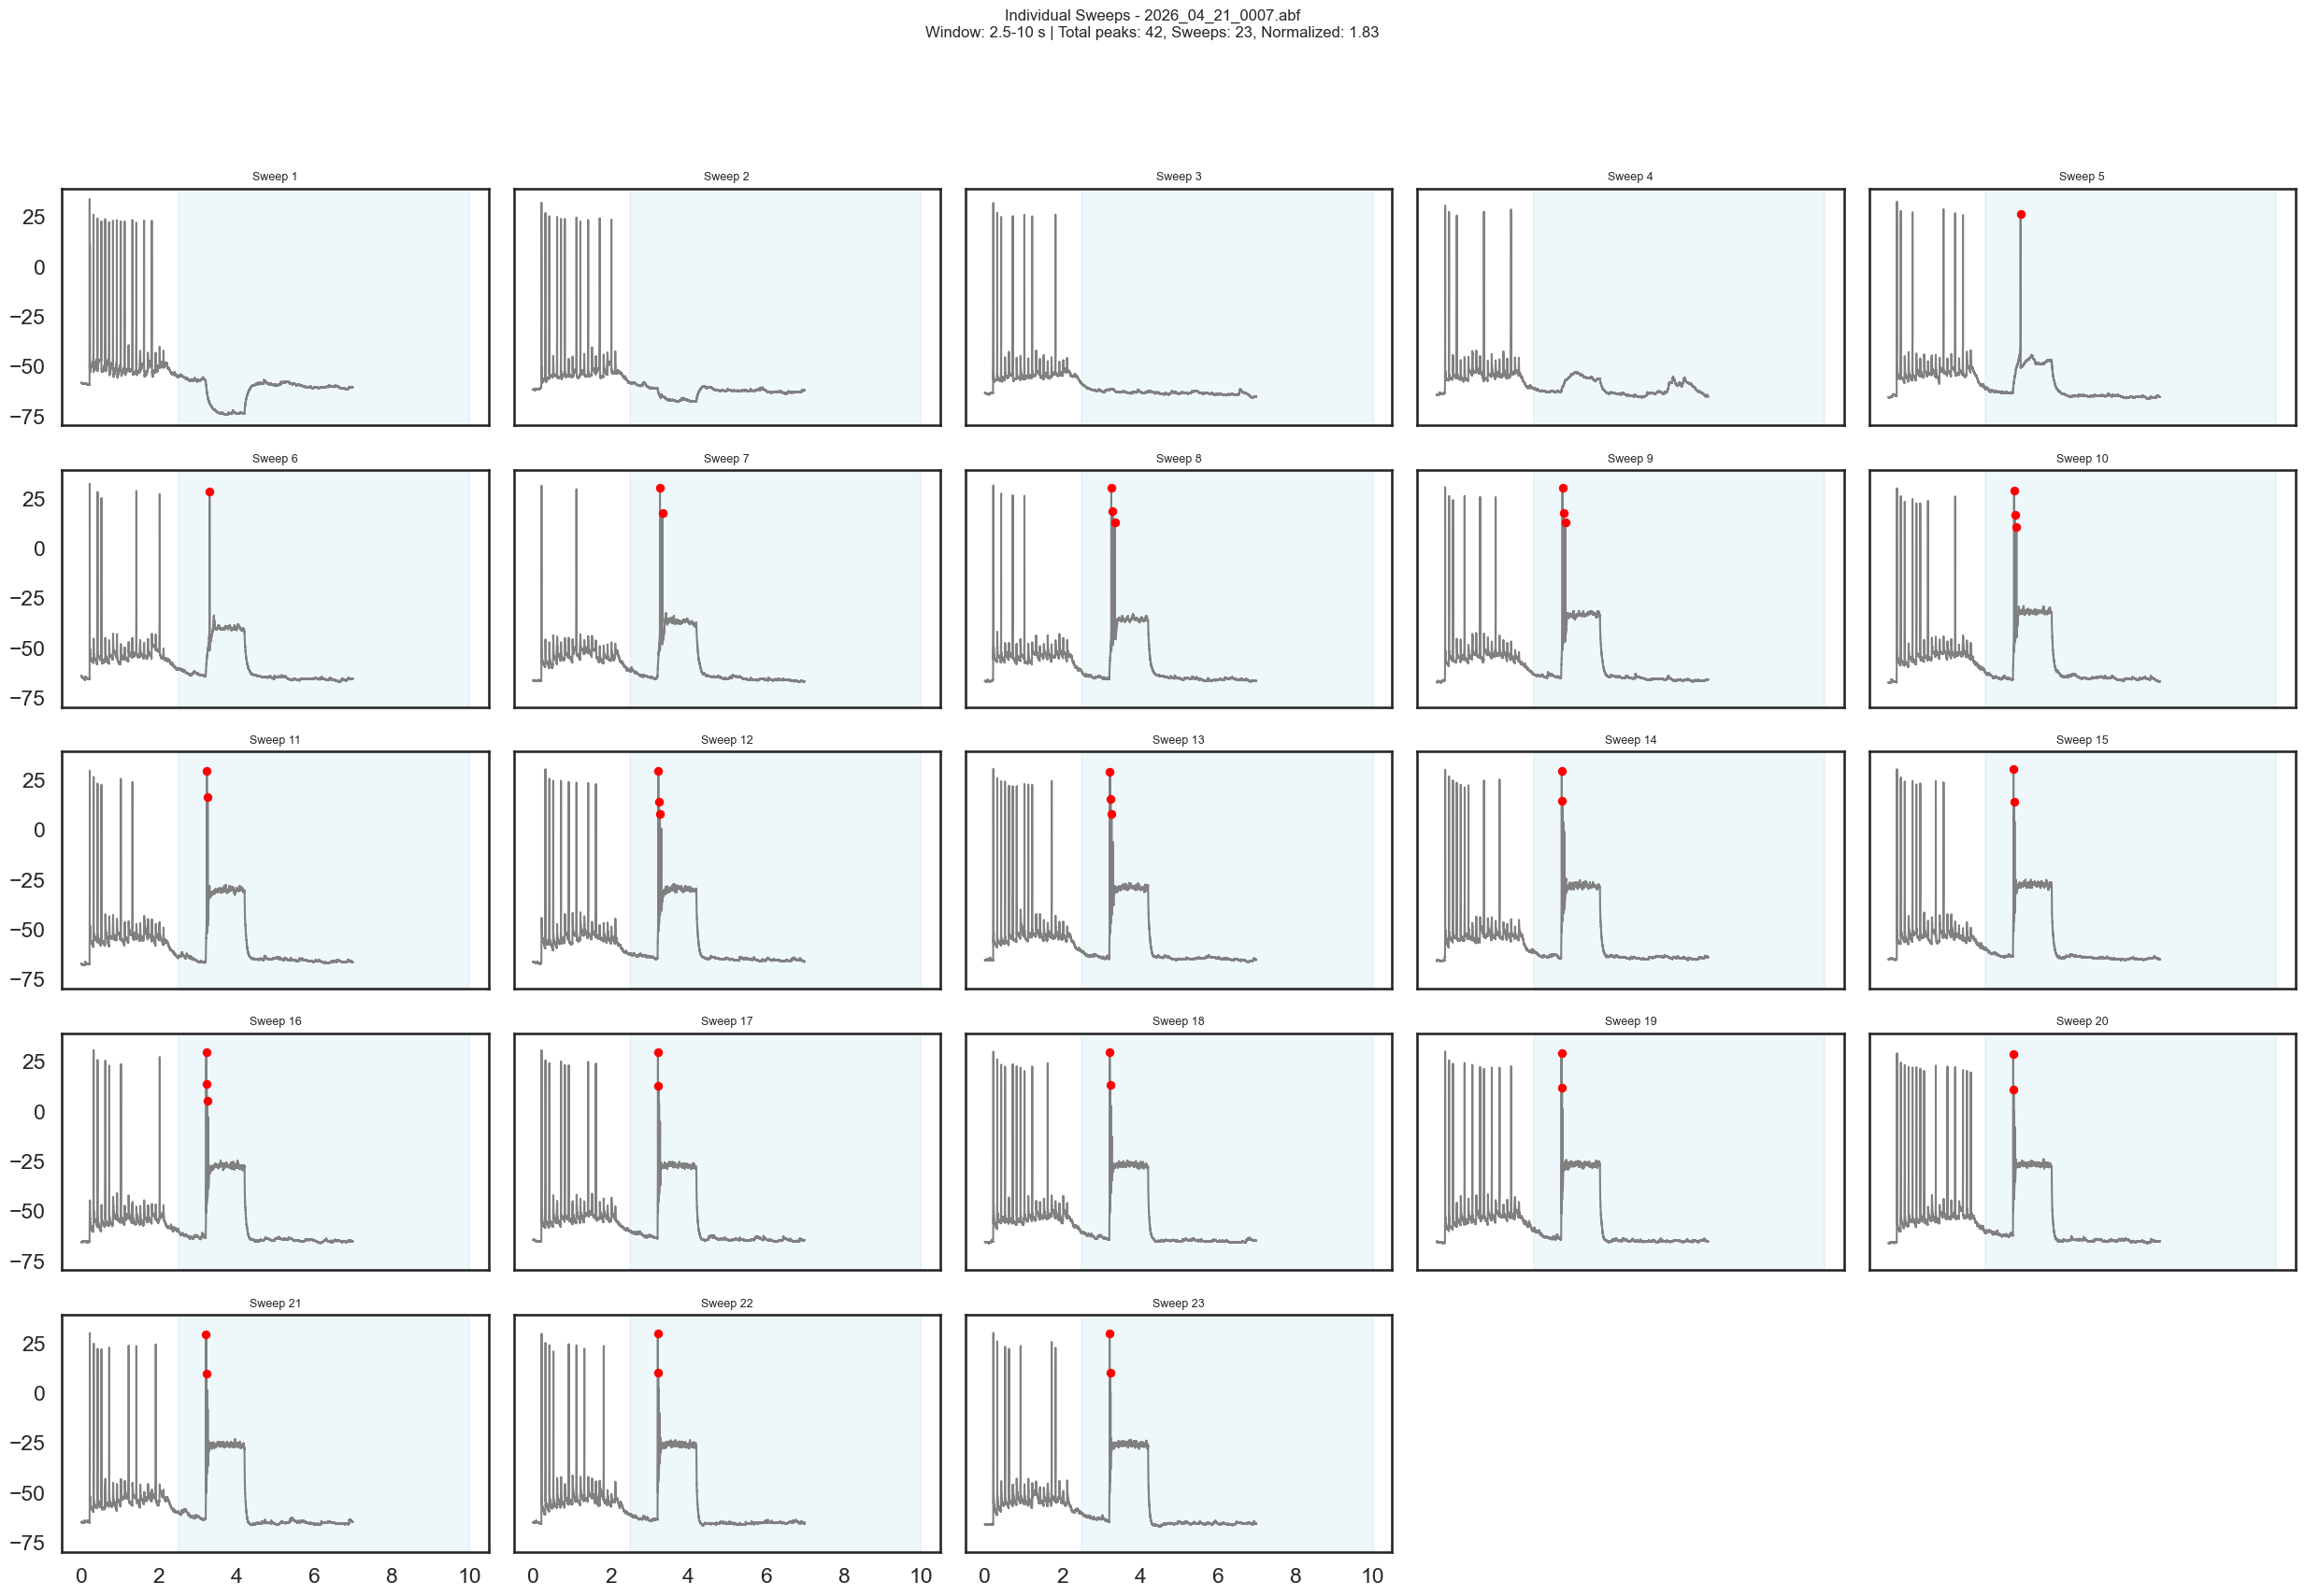

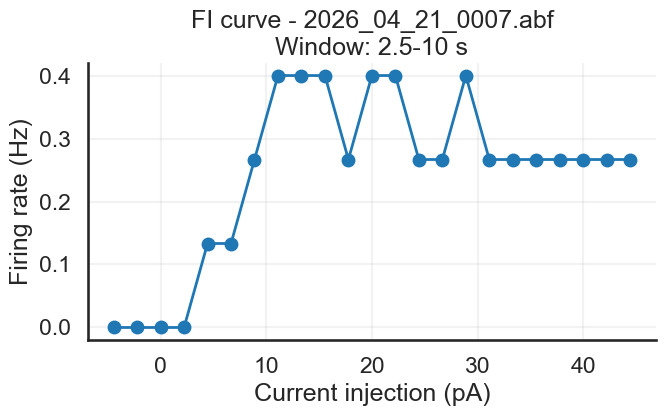

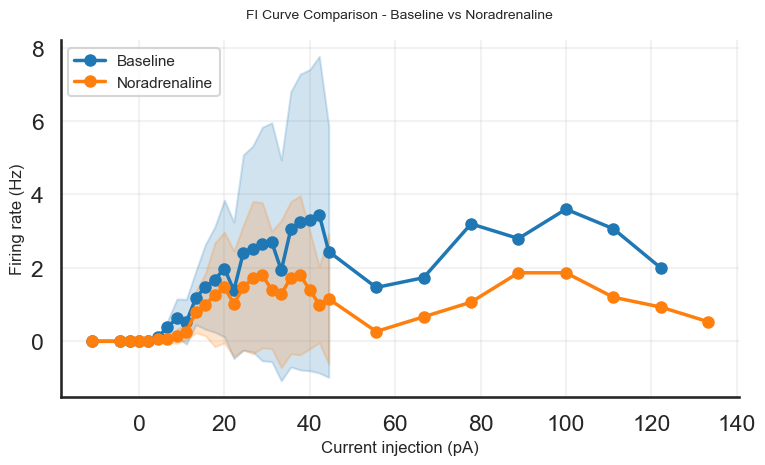

OSError: Cannot save file into a non-existent directory: '/Users/rbondare/rbondare/ephys/results'

In [11]:
import numpy as np
import pyabf
import matplotlib.pyplot as plt
import seaborn as sns
import os
import pandas as pd
from ephys.ephys_functions import detect_peaks

sns.set_context("talk")
sns.set_style("white")

base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/20.04.2026"

# Dictionary to organize files by condition with their detection windows
abf_files_dict = {
    "baseline": [
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0021.abf"), "detection_window": (0, 10)},
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0026.abf"), "detection_window": (2.5, 10)},
        {"file": os.path.join(base_dir, "21.04.2026 M2/2026_04_21_0006.abf"), "detection_window": (2.5, 10)}
    ],
    "noradrenaline": [
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0022.abf"), "detection_window": (2.5, 10)},
        {"file": os.path.join(base_dir, "20.04.2026 M1/2026_04_20_0027.abf"), "detection_window": (2.5, 10)},
        {"file": os.path.join(base_dir, "21.04.2026 M2/2026_04_21_0007.abf"), "detection_window": (2.5, 10)}
    ]
}

results_output_path = os.path.expanduser("~/rbondare/ephys/results/fi_results_table.csv")

def count_and_plot_peaks_per_sweep(
    abf_file,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    detection_window=(2.5, 10.0),
    ):
    abf = pyabf.ABF(abf_file)
    n_sweeps = len(abf.sweepList)
    window_seconds = detection_window[1] - detection_window[0]

    if window_seconds <= 0:
        raise ValueError("detection_window must have end > start")

    per_sweep = []

    # Figure 1: original sweep layout with peaks marked
    n_cols = 5
    n_rows = int(np.ceil(n_sweeps / n_cols))
    fig_sweeps, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 3.5 * n_rows),
        sharex=True,
        sharey=True
    )
    axes = np.atleast_1d(axes).ravel()

    for sweep in abf.sweepList:
        abf.setSweep(sweep)
        x = abf.sweepX
        y = abf.sweepY

        window_mask = (x >= detection_window[0]) & (x <= detection_window[1])
        y_window = y[window_mask]

        if y_window.size > 0:
            peaks_window, _ = detect_peaks(
                y_window,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
            )
            peaks = np.where(window_mask)[0][peaks_window]
            n_peaks = int(len(peaks_window))
        else:
            peaks = np.array([], dtype=int)
            n_peaks = 0

        firing_rate_hz = n_peaks / window_seconds
        
        # Extract actual current from stimulus channel (sweepC)
        # Take the mean value during the detection window as the injected current
        current_window = abf.sweepC[window_mask]
        if current_window.size > 0:
            current_pA = float(np.mean(current_window))
        else:
            current_pA = float(current_start_pA + sweep * current_step_pA)

        per_sweep.append({
            "File": os.path.basename(abf_file),
            "Sweep": int(sweep + 1),
            "Current_pA": current_pA,
            "Peaks_in_Window": n_peaks,
            "FiringRate_Hz": float(firing_rate_hz),
        })

        ax = axes[sweep]
        ax.plot(x, y, color="gray", linewidth=1.5)
        ax.axvspan(detection_window[0], detection_window[1], color="lightblue", alpha=0.2)
        if n_peaks > 0:
            ax.scatter(x[peaks], y[peaks], color="red", s=28, zorder=3)
        ax.set_title(f"Sweep {sweep + 1}", fontsize=9)

    for j in range(n_sweeps, len(axes)):
        axes[j].axis("off")
    for ax in axes[:n_sweeps]:
        ax.label_outer()

    total_peaks = int(sum(item["Peaks_in_Window"] for item in per_sweep))
    norm_spikes = total_peaks / n_sweeps if n_sweeps > 0 else 0

    fig_sweeps.suptitle(
        f"Individual Sweeps - {os.path.basename(abf_file)}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s | "
        f"Total peaks: {total_peaks}, Sweeps: {n_sweeps}, Normalized: {norm_spikes:.2f}",
        fontsize=12
    )
    fig_sweeps.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

    # Figure 2: FI curve for this file
    sweep_df = pd.DataFrame(per_sweep)
    fig_fi, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(sweep_df["Current_pA"], sweep_df["FiringRate_Hz"], marker="o", linewidth=2)
    ax.set_xlabel("Current injection (pA)")
    ax.set_ylabel("Firing rate (Hz)")
    ax.set_title(
        f"FI curve - {os.path.basename(abf_file)}\n"
        f"Window: {detection_window[0]}-{detection_window[1]} s"
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return sweep_df


def plot_fi_curves_comparison(
    abf_files_dict,
    height_threshold=5,
    prominence_min=0.1,
    distance_min=5,
    ):
    """
    Process multiple files for different conditions and plot mean FI curves.
    
    Parameters:
    -----------
    abf_files_dict : dict
        Dictionary with condition names as keys and lists of dicts as values
        Each dict should contain "file" (path) and "detection_window" (tuple)
        e.g., {"baseline": [{"file": "path.abf", "detection_window": (0, 10)}, ...]}
    """
    all_results = []
    condition_data = {}
    
    # Process all files and collect results
    for condition, abf_file_list in abf_files_dict.items():
        condition_dfs = []
        
        for file_dict in abf_file_list:
            abf_file = file_dict["file"]
            detection_window = file_dict["detection_window"]
            
            sweep_df = count_and_plot_peaks_per_sweep(
                abf_file,
                height_threshold=height_threshold,
                prominence_min=prominence_min,
                distance_min=distance_min,
                detection_window=detection_window,
            )
            sweep_df["Condition"] = condition
            condition_dfs.append(sweep_df)
            all_results.append(sweep_df)
        
        # Combine all files for this condition
        condition_combined = pd.concat(condition_dfs, ignore_index=True)
        condition_data[condition] = condition_combined
    
    # Calculate mean firing rate per current level for each condition
    fig_comparison, ax = plt.subplots(figsize=(8, 5))
    colors = {"baseline": "#1f77b4", "noradrenaline": "#ff7f0e"}
    
    for condition, df in condition_data.items():
        # Group by current and calculate mean firing rate
        mean_fr = df.groupby("Current_pA")["FiringRate_Hz"].mean()
        std_fr = df.groupby("Current_pA")["FiringRate_Hz"].std()
        
        ax.plot(
            mean_fr.index,
            mean_fr.values,
            marker="o",
            linewidth=2.5,
            label=condition.capitalize(),
            color=colors.get(condition, None),
            markersize=8
        )
        ax.fill_between(
            mean_fr.index,
            mean_fr.values - std_fr.values,
            mean_fr.values + std_fr.values,
            alpha=0.2,
            color=colors.get(condition, None)
        )
    
    ax.set_xlabel("Current injection (pA)", fontsize=12)
    ax.set_ylabel("Firing rate (Hz)", fontsize=12)
    ax.set_title(
        f"FI Curve Comparison - Baseline vs Noradrenaline\n",
        fontsize=10
    )
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=11, loc="upper left")
    plt.tight_layout()
    plt.show()
    
    # Combine all results and save to CSV
    full_results_df = pd.concat(all_results, ignore_index=True)
    full_results_df.to_csv(results_output_path, index=False)
    print(f"Results saved to {results_output_path}")
    
    return full_results_df, condition_data


# Main execution
if __name__ == "__main__":
    all_results, condition_data = plot_fi_curves_comparison(
        abf_files_dict,
        height_threshold=5,
        prominence_min=0.1,
        distance_min=5,
    )

Plotting voltage clamp from the same experiments
unclear how to analyse the VC clamp recordings, for now just leaving it here like this for visualisation without analysis

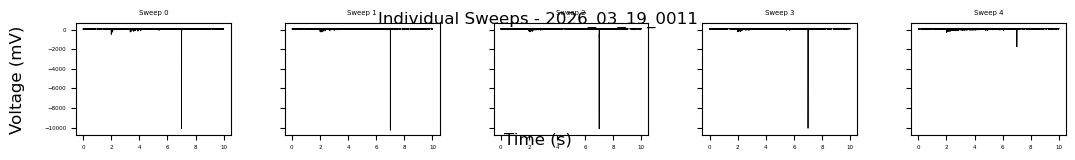

In [7]:
%matplotlib inline
import pyabf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import math

base_dir = "/Volumes/joeschgrp/Group Members/Rima/Ephys_NE/DATA/double_opto/19.03.2026_control"

abf = pyabf.ABF(os.path.join(base_dir, "19.03.2026 M2/2026_03_19_0011.abf"))

#xlim = [0.45, 0.6] #for subplots of 500 ms opto stim 
#xlim = [0.03, 0.15] #for subplots of 80 ms opto stim 
#ylim = [-80, 70]
num_sweeps = len(abf.sweepList)
cols = 5  # Number of columns for subplots
rows = int(np.ceil(num_sweeps / cols))

# Give the figure a little more breathing room so titles/labels fit cleanly
fig, axes = plt.subplots(
    rows, cols,
    figsize=(cols * 2.2, rows * 1.4),
    sharex=True,
    sharey=True
 )

fig.suptitle(f"Individual Sweeps - {abf.abfID}")

# Flatten axs array to handle both 1D and 2D cases
axs = axes.flatten()

for i, sweep in enumerate(abf.sweepList):
    abf.setSweep(sweep)
    axs[i].plot(abf.sweepX, abf.sweepY, color='black', linewidth=0.6)
    axs[i].set_title(f"Sweep {sweep}", fontsize=5)
    #axs[i].set_xlim(xlim)
    #axs[i].set_ylim(ylim)
    axs[i].tick_params(labelbottom=True, labelsize=4)

# Hide unused subplots
for j in range(num_sweeps, len(axs)):
    axs[j].axis("off")

fig.supxlabel("Time (s)")
fig.supylabel("Voltage (mV)")
fig.subplots_adjust(top=0.90, left=0.08, right=0.98, bottom=0.10, wspace=0.35, hspace=0.45)

plt.show()